# KOSPI200 LSTM Sequence Baseline v3

이 노트북은 기존 LightGBM baseline을 **최근 20거래일 OHLCV/기술지표 시퀀스를 직접 입력하는 LSTM 모델**로 리팩토링한 버전입니다.

핵심 변경점은 다음과 같습니다.

```text
기존 방식:
  특정 종목의 특정 날짜 1행 피처 → LightGBM → 미래 수익률 예측

개선 방식:
  특정 종목의 최근 20거래일 피처 배열 → LSTM → 1/7/30거래일 후 초과수익률 예측
```

반영한 개선사항:

1. 평가용 `eval_model`과 최종 예측용 `final_model` 분리
2. Top5 평가 누수 제거
3. walk-forward validation 추가
4. target을 단순수익률에서 시장/업종 대비 초과수익률로 변경 가능
5. TopK 기반 간단 백테스트 추가
6. 기존 1행 tabular 방식과 비교할 수 있도록 결과 구조 분리

## 1. 라이브러리 설치

Colab에서 실행할 경우 아래 셀을 먼저 실행합니다.

- `torch`: LSTM 모델 학습
- `pyarrow`: parquet 파일 로드
- `tqdm`: 학습 진행률 표시
- `scikit-learn`: 결측치 처리, 스케일링, 평가 지표

In [1]:
%pip -q install torch pyarrow tqdm scikit-learn matplotlib

## 2. 기본 설정 및 라이브러리 import

처음에는 아래 설정만 주로 수정하면 됩니다.

- `PARQUET_PATH`: 입력 데이터 파일 경로
- `LOOKBACK`: 모델에 넣을 과거 거래일 수. 기본값은 20
- `HORIZONS`: 예측할 미래 기간. 기본값은 1, 7, 30거래일
- `TARGET_MODE`: 예측 target 정의
  - `raw`: 단순 미래 수익률
  - `market_excess`: 같은 날짜 전체 종목 평균 대비 초과수익률
  - `sector_excess`: 같은 날짜 같은 업종 평균 대비 초과수익률

In [27]:
import gc
import random
import warnings
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from tqdm.auto import tqdm

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 140)


@dataclass
class CFG:
    # ------------------------------------------------------------
    # 데이터 관련 설정
    # ------------------------------------------------------------
    PARQUET_PATH: Path = Path("/content/master_panel_v9.parquet")
    USE_ONLY_KOSPI200_UNIVERSE: bool = True

    # ------------------------------------------------------------
    # 시퀀스/타깃 설정
    # ------------------------------------------------------------
    LOOKBACK: int = 20
    HORIZONS: tuple = (1, 7, 30)

    # raw / market_excess / sector_excess 중 선택
    TARGET_MODE: str = "market_excess"

    # 너무 큰 이상치 target이 학습을 망치는 것을 막기 위한 clip 범위
    # 예: -0.5 ~ +0.5 = -50% ~ +50%
    TARGET_CLIP: tuple = (-0.50, 0.50)

    # ------------------------------------------------------------
    # 학습 설정
    # ------------------------------------------------------------
    MODEL_TYPE: str = "LSTM"  # 현재 기본값은 LSTM. GRU로 바꾸려면 아래 모델 클래스 참고.
    HIDDEN_SIZE: int = 32
    NUM_LAYERS: int = 1
    DROPOUT: float = 0.20
    BATCH_SIZE: int = 128
    EPOCHS: int = 20
    LEARNING_RATE: float = 1e-3
    WEIGHT_DECAY: float = 1e-5
    PATIENCE: int = 5
    GRAD_CLIP_NORM: float = 1.0

    # ------------------------------------------------------------
    # 평가/백테스트 설정
    # ------------------------------------------------------------
    TOP_K: int = 5
    TRANSACTION_COST: float = 0.001  # 0.1% 가정. 필요하면 0으로 변경.

    # ------------------------------------------------------------
    # 기타
    # ------------------------------------------------------------
    RANDOM_STATE: int = 42
    NUM_WORKERS: int = 0

    # ------------------------------------------------------------
    # 메모리 절약 설정
    # ------------------------------------------------------------
    # True: X_train 전체 3차원 배열을 만들지 않고 Dataset에서 필요한 시퀀스만 즉석 생성합니다.
    MEMORY_SAFE_MODE: bool = True

    # 피처가 너무 많으면 RAM/GPU 메모리와 학습 시간이 급격히 증가합니다.
    # None이면 전체 피처를 사용하고, 숫자를 넣으면 앞에서부터 N개만 사용합니다.
    MAX_FEATURES: int | None = 60

    # walk-forward 검증 후 최신일 예측용 final_model까지 학습할지 여부입니다.
    # T4 RAM이 부족하면 False로 두고, 검증 결과 확인 후 별도 런에서 True로 바꾸는 것을 권장합니다.
    RUN_FINAL_MODEL: bool = True

    # fold별 모델 객체를 리스트에 보관하면 메모리가 누적됩니다. 보통 False 권장.
    KEEP_EVAL_MODELS: bool = False

    DEVICE: str = "cuda" if torch.cuda.is_available() else "cpu"


def seed_everything(seed: int = 42):
    """실험 재현성을 위해 난수 시드를 고정합니다."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

seed_everything(CFG.RANDOM_STATE)
print("device:", CFG.DEVICE)

device: cuda


## 3. 데이터 로드 및 기본 정리

입력 parquet는 최소한 아래 컬럼을 포함해야 합니다.

```text
date, ticker, open, high, low, close, volume
```

있으면 추가로 사용하는 컬럼:

```text
market_cap, trading_value, is_pit_universe_kospi200, sector, industry
```

In [8]:
def normalize_ticker(x):
    """종목코드를 항상 6자리 문자열로 맞춥니다. 예: 5930 -> '005930'"""
    return str(x).replace(".0", "").zfill(6)


def load_panel_data(path: Path) -> pd.DataFrame:
    """parquet 파일을 읽고 기본 컬럼 형식을 정리합니다."""
    if not path.exists():
        raise FileNotFoundError(
            f"입력 parquet 파일이 없습니다: {path}"
        )

    df = pd.read_parquet(path)

    # 컬럼명 앞뒤 공백 제거
    df.columns = [str(c).strip() for c in df.columns]

    required = ["date", "ticker", "open", "high", "low", "close", "volume"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"필수 컬럼이 없습니다: {missing}")

    df["date"] = pd.to_datetime(df["date"])
    df["ticker"] = df["ticker"].map(normalize_ticker)

    # 숫자로 변환해야 하는 기본 컬럼
    for col in ["open", "high", "low", "close", "volume", "market_cap", "trading_value"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # 중복 제거 후 시계열 순서 정렬
    df = df.drop_duplicates(["date", "ticker"], keep="last")
    df = df.sort_values(["ticker", "date"]).reset_index(drop=True)

    if CFG.USE_ONLY_KOSPI200_UNIVERSE and "is_pit_universe_kospi200" in df.columns:
        before = len(df)
        df = df[df["is_pit_universe_kospi200"] == 1].copy().reset_index(drop=True)
        print(f"KOSPI200 유니버스 필터링: {before:,}행 -> {len(df):,}행")

    print("데이터 로드 완료")
    print("shape:", df.shape)
    print("기간:", df["date"].min().date(), "~", df["date"].max().date())
    print("종목 수:", df["ticker"].nunique())
    display(df.head())
    return df


df = load_panel_data(CFG.PARQUET_PATH)

KOSPI200 유니버스 필터링: 1,237,580행 -> 783,759행
데이터 로드 완료
shape: (783759, 114)
기간: 2010-01-04 ~ 2025-12-30
종목 수: 368


,date,ticker,open,high,low,close,volume,market_cap,listed_shares,trading_value,inst_net,corp_net,indiv_net,foreign_net,total_net,log_return,foreign_net_pct,inst_net_pct,indiv_net_pct,corp_net_pct,rsi_14,macd,macd_hist,macd_signal,bb_lower,bb_middle,bb_upper,bb_pct,atr_14,atr_pct,sma_20,sma_60,ema_12,ema_26,volatility_20,split_ratio_today,days_since_split,is_post_split_30d,is_volume_zero,is_halt_resume,kospi_close,kospi_return,kospi_volatility_20,is_market_stress,excess_return,volume_norm_30,macd_z252,rsi_z63,atr_pct_z252,macro_kor_base_rate,macro_usdkrw,macro_kor_bond_3y,macro_cpi,macro_ip,macro_m2,macro_export,macro_gdp_real,macro_usdkrw_chg_5d,macro_usdkrw_chg_20d,macro_cpi_yoy,macro_gdp_yoy,macro_export_yoy,macro_m2_yoy,macro_kor_base_rate_chg_1m,macro_kor_bond_3y_chg_5d,short_volume,short_total_volume,short_ratio_pct,short_volume_pct_volume,days_since_listing,days_to_delisting,is_pre_delisting_30d,is_short_ban,is_pit_universe_kospi200,price_limit_pct,is_lower_limit_hit,is_upper_limit_hit,is_boundary_2014_residual,label_fwd_5d,label_fwd_20d,label_tb_20d,high_adj,is_high_corrected,is_listed_shares_event,is_macro_release_day_monthly,is_lower_limit_loose,revenue,operating_inc,net_income,total_assets,total_equity,revenue_yoy_growth,operating_inc_yoy_growth,net_income_yoy_growth,opm_ttm,npm_ttm,roe_ttm,roa_ttm,debt_ratio,earning_surprise,revenue_z,operating_inc_z,net_income_z,total_assets_z,total_equity_z,revenue_yoy_growth_z,operating_inc_yoy_growth_z,net_income_yoy_growth_z,opm_ttm_z,npm_ttm_z,roe_ttm_z,roa_ttm_z,debt_ratio_z,earning_surprise_z
0,2010-01-04,000020,7540,7820,7480,7520,176987,2.100447e+11,27931470.0,1.346213e+09,-515869940.0,104715300.0,313973940.0,97180700.0,0.0,NaN,0.000463,-0.002456,0.001495,0.000499,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,-1,0,0,0,1696.14,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,2.0,1167.6,4.44,85.351,79.3,1402555.5,30735415,386238.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,5839,0,0,1,15,0,0,0,-0.057471,-0.232496,<NA>,7820,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2010-01-05,000020,7490,7580,7350,7500,214214,2.094860e+11,27931470.0,1.595967e+09,-552327500.0,-51595600.0,590648400.0,13274700.0,0.0,-0.002663,0.000063,-0.002637,0.002820,-0.000246,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,-1,0,0,0,1690.62,-0.003260,NaN,0.0,0.000597,NaN,NaN,NaN,NaN,2.0,1156.2,4.36,85.351,79.3,1402555.5,30735415,386238.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,5838,0,0,1,15,0,0,0,-0.060458,-0.267444,<NA>,7580,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2010-01-06,000020,7500,7500,7320,7350,81868,2.052963e+11,27931470.0,6.059583e+08,2471300.0,90186400.0,-134749500.0,42091800.0,0.0,-0.020203,0.000205,0.000012,-0.000656,0.000439,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,-1,0,0,0,1705.32,0.008657,NaN,0.0,-0.028860,NaN,NaN,NaN,NaN,2.0,1144.3,4.43,85.351,79.3,1402555.5,30735415,386238.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,5837,0,0,1,15,0,0,0,-0.073376,-0.223144,<NA>,7500,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2010-01-07,000020,7350,7420,7200,7210,106385,2.013859e+11,27931470.0,7.777280e+08,-96078300.0,44004800.0,-26524200.0,78597700.0,0.0,-0.019231,0.000390,-0.000477,-0.000132,0.000219,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,-1,0,0,0,1683.45,-0.012908,NaN,0.0,-0.006324,NaN,NaN,NaN,NaN,2.0,1138.2,4.32,85.351,79.3,1402555.5,30735415,386238.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,5836,0,0,1,15,0,0,0,-0.054144,-0.178722,<NA>,7420,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2010-01-08,000020,7220,7330,7220,7240,61023,2.022238e+11,27931470.0,4.454789e+08,-165739700.0,210196

## 4. 피처 생성

LSTM에는 최근 20거래일의 피처 배열을 넣습니다.

이때 `open/high/low/close` 같은 절대 가격을 그대로 넣기보다, **수익률, 변동성, 이동평균 괴리율, 거래량 변화율**처럼 종목 간 비교 가능한 값으로 바꾸는 것이 더 안정적입니다.

다만 모델이 캔들 구조를 볼 수 있도록 OHLC를 전일 종가 대비 비율로 변환한 피처도 추가합니다.

In [9]:
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    """LSTM 입력으로 사용할 시계열 피처를 생성합니다."""
    df = df.copy()
    df = df.sort_values(["ticker", "date"]).reset_index(drop=True)
    g = df.groupby("ticker", sort=False)

    # ------------------------------------------------------------
    # 1) 전일 종가 기준 OHLC 위치
    # 절대 가격 대신 비율을 사용합니다.
    # 예: open_to_prev_close = 오늘 시가 / 전일 종가 - 1
    # ------------------------------------------------------------
    prev_close = g["close"].shift(1)
    for col in ["open", "high", "low", "close"]:
        df[f"{col}_to_prev_close"] = df[col] / prev_close - 1

    # ------------------------------------------------------------
    # 2) 과거 수익률
    # ------------------------------------------------------------
    for w in [1, 2, 5, 10, 20, 60]:
        df[f"ret_{w}d"] = g["close"].pct_change(w, fill_method=None)

    # ------------------------------------------------------------
    # 3) 이동평균 괴리율
    # close / moving_average - 1
    # 현재 가격이 이동평균보다 얼마나 높은지/낮은지 나타냅니다.
    # ------------------------------------------------------------
    for w in [5, 10, 20, 60]:
        ma = g["close"].transform(lambda x: x.rolling(w, min_periods=w).mean())
        df[f"ma_gap_{w}d"] = df["close"] / ma - 1

    # ------------------------------------------------------------
    # 4) 변동성
    # 최근 N일 수익률의 표준편차입니다.
    # ------------------------------------------------------------
    for w in [5, 20, 60]:
        df[f"volatility_{w}d"] = g["ret_1d"].transform(lambda x: x.rolling(w, min_periods=w).std())

    # ------------------------------------------------------------
    # 5) 거래량/거래대금 관련 피처
    # ------------------------------------------------------------
    df["log_volume"] = np.log1p(df["volume"].clip(lower=0))
    volume_ma20 = g["volume"].transform(lambda x: x.rolling(20, min_periods=20).mean())
    df["volume_ratio_20d"] = df["volume"] / volume_ma20 - 1

    if "trading_value" in df.columns:
        df["log_trading_value"] = np.log1p(df["trading_value"].clip(lower=0))
    else:
        # 거래대금 컬럼이 없으면 close * volume으로 대략 계산합니다.
        df["log_trading_value"] = np.log1p((df["close"] * df["volume"]).clip(lower=0))

    if "market_cap" in df.columns:
        df["log_market_cap"] = np.log1p(df["market_cap"].clip(lower=0))

    # ------------------------------------------------------------
    # 6) 시장 공통 피처
    # 날짜별 전체 종목 평균 수익률과 변동성을 계산합니다.
    # 이 값은 해당 날짜 장 종료 후에는 알 수 있는 값이라는 가정입니다.
    # ------------------------------------------------------------
    market_daily = (
        df.groupby("date", as_index=False)
          .agg(
              market_ret_1d=("ret_1d", "mean"),
              market_ret_5d=("ret_5d", "mean"),
              market_volatility_20d=("volatility_20d", "mean"),
          )
    )
    df = df.merge(market_daily, on="date", how="left")

    # ------------------------------------------------------------
    # 7) 업종 피처
    # sector 또는 industry 컬럼이 있으면 업종 평균 수익률을 추가합니다.
    # ------------------------------------------------------------
    sector_col = None
    for c in ["sector", "industry"]:
        if c in df.columns and df[c].notna().sum() > 0:
            sector_col = c
            break

    if sector_col is not None:
        sector_daily = (
            df.groupby(["date", sector_col], dropna=False, as_index=False)
              .agg(
                  sector_ret_1d=("ret_1d", "mean"),
                  sector_ret_5d=("ret_5d", "mean"),
                  sector_volatility_20d=("volatility_20d", "mean"),
              )
        )
        df = df.merge(sector_daily, on=["date", sector_col], how="left")
        print("업종 피처 사용 컬럼:", sector_col)
    else:
        print("업종 컬럼이 없어 업종 피처는 생성하지 않았습니다.")

    # ------------------------------------------------------------
    # 8) 날짜 피처
    # ------------------------------------------------------------
    df["month"] = df["date"].dt.month
    df["dayofweek"] = df["date"].dt.dayofweek

    return df.sort_values(["ticker", "date"]).reset_index(drop=True)


df = add_features(df)
display(df.head())

업종 컬럼이 없어 업종 피처는 생성하지 않았습니다.


,date,ticker,open,high,low,close,volume,market_cap,listed_shares,trading_value,inst_net,corp_net,indiv_net,foreign_net,total_net,log_return,foreign_net_pct,inst_net_pct,indiv_net_pct,corp_net_pct,rsi_14,macd,macd_hist,macd_signal,bb_lower,bb_middle,bb_upper,bb_pct,atr_14,atr_pct,sma_20,sma_60,ema_12,ema_26,volatility_20,split_ratio_today,days_since_split,is_post_split_30d,is_volume_zero,is_halt_resume,kospi_close,kospi_return,kospi_volatility_20,is_market_stress,excess_return,volume_norm_30,macd_z252,rsi_z63,atr_pct_z252,macro_kor_base_rate,macro_usdkrw,macro_kor_bond_3y,macro_cpi,macro_ip,macro_m2,macro_export,macro_gdp_real,macro_usdkrw_chg_5d,macro_usdkrw_chg_20d,macro_cpi_yoy,...,label_tb_20d,high_adj,is_high_corrected,is_listed_shares_event,is_macro_release_day_monthly,is_lower_limit_loose,revenue,operating_inc,net_income,total_assets,total_equity,revenue_yoy_growth,operating_inc_yoy_growth,net_income_yoy_growth,opm_ttm,npm_ttm,roe_ttm,roa_ttm,debt_ratio,earning_surprise,revenue_z,operating_inc_z,net_income_z,total_assets_z,total_equity_z,revenue_yoy_growth_z,operating_inc_yoy_growth_z,net_income_yoy_growth_z,opm_ttm_z,npm_ttm_z,roe_ttm_z,roa_ttm_z,debt_ratio_z,earning_surprise_z,open_to_prev_close,high_to_prev_close,low_to_prev_close,close_to_prev_close,ret_1d,ret_2d,ret_5d,ret_10d,ret_20d,ret_60d,ma_gap_5d,ma_gap_10d,ma_gap_20d,ma_gap_60d,volatility_5d,volatility_20d,volatility_60d,log_volume,volume_ratio_20d,log_trading_value,log_market_cap,market_ret_1d,market_ret_5d,market_volatility_20d,month,dayofweek
0,2010-01-04,000020,7540,7820,7480,7520,176987,2.100447e+11,27931470.0,1.346213e+09,-515869940.0,104715300.0,313973940.0,97180700.0,0.0,NaN,0.000463,-0.002456,0.001495,0.000499,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,-1,0,0,0,1696.14,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,2.0,1167.6,4.44,85.351,79.3,1402555.5,30735415,386238.5,NaN,NaN,NaN,...,<NA>,7820,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.083837,NaN,21.020561,26.070586,NaN,NaN,NaN,1,0
1,2010-01-05,000020,7490,7580,7350,7500,214214,2.094860e+11,27931470.0,1.595967e+09,-552327500.0,-51595600.0,590648400.0,13274700.0,0.0,-0.002663,0.000063,-0.002637,0.002820,-0.000246,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,-1,0,0,0,1690.62,-0.003260,NaN,0.0,0.000597,NaN,NaN,NaN,NaN,2.0,1156.2,4.36,85.351,79.3,1402555.5,30735415,386238.5,NaN,NaN,NaN,...,<NA>,7580,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.003989,0.007979,-0.022606,-0.002660,-0.002660,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.274735,NaN,21.190746,26.067923,-0.002435,NaN,NaN,1,1
2,2010-01-06,000020,7500,7500,7320,7350,81868,2.052963e+11,27931470.0,6.059583e+08,2471300.0,90186400.0,-134749500.0,42091800.0,0.0,-0.020203,0.000205,0.000012,-0.000656,0.000439,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,-1,0,0,0,1705.32,0.008657,NaN,0.0,-0.028860,NaN,NaN,NaN,NaN,2.0,1144.3,4.43,85.351,79.3,1402555.5,30735415,386238.5,NaN,NaN,NaN,...,<NA>,7500,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,-0.024000,-0.020000,-0.020000,-0.022606,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.312876,NaN,20.222322,26.047720,0.006474,NaN,NaN,1,2
3,2010-01-07,000020,7350,7420,7200,7210,106385,2.013859e+11,27931470.0,7.777280e+08,-96078300.0,44004800.0,-26524200.0,78597700.0,0.0,-0.019231,0.000390,-0.000477,-0.000132,0.000219,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,-1,0,0,0,1683.45,-0.012908,NaN,0.0,-0.006324,NaN,NaN,NaN,NaN,2.0,1138.2,4.32,85.351,79.3,1402555.5,30735415,386238.5,NaN,NaN,NaN,...,<NA>,7420,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.

## 5. Target 생성: 단순수익률 → 초과수익률

기본 target은 `market_excess`입니다.

```text
raw_return_h = h거래일 후 종가 / 오늘 종가 - 1
market_excess_h = raw_return_h - 같은 날짜 전체 종목 평균 raw_return_h
sector_excess_h = raw_return_h - 같은 날짜 같은 업종 평균 raw_return_h
```

이렇게 바꾸는 이유는 모델이 “시장이 전체적으로 오른 날”을 맞히는 것이 아니라, **같은 시장 안에서 상대적으로 더 강한 종목**을 찾도록 만들기 위해서입니다.

In [10]:
def add_targets(df: pd.DataFrame) -> pd.DataFrame:
    """미래 수익률 target과 초과수익률 target을 생성합니다."""
    df = df.copy().sort_values(["ticker", "date"]).reset_index(drop=True)
    g = df.groupby("ticker", sort=False)

    sector_col = None
    for c in ["sector", "industry"]:
        if c in df.columns and df[c].notna().sum() > 0:
            sector_col = c
            break

    for h in CFG.HORIZONS:
        raw_col = f"raw_return_{h}d"
        market_col = f"market_excess_return_{h}d"
        sector_col_out = f"sector_excess_return_{h}d"
        final_col = f"target_{h}d"

        # h거래일 뒤 종가 기준 단순수익률
        future_close = g["close"].shift(-h)
        df[raw_col] = future_close / df["close"] - 1

        # 같은 날짜의 전체 종목 평균 미래수익률을 뺀 값
        market_avg = df.groupby("date")[raw_col].transform("mean")
        df[market_col] = df[raw_col] - market_avg

        # 같은 날짜, 같은 업종 평균 미래수익률을 뺀 값
        if sector_col is not None:
            sector_avg = df.groupby(["date", sector_col], dropna=False)[raw_col].transform("mean")
            df[sector_col_out] = df[raw_col] - sector_avg
        else:
            df[sector_col_out] = np.nan

        # 실제 학습에 사용할 target 선택
        if CFG.TARGET_MODE == "raw":
            df[final_col] = df[raw_col]
        elif CFG.TARGET_MODE == "market_excess":
            df[final_col] = df[market_col]
        elif CFG.TARGET_MODE == "sector_excess":
            if sector_col is None:
                raise ValueError("TARGET_MODE='sector_excess'를 사용하려면 sector 또는 industry 컬럼이 필요합니다.")
            df[final_col] = df[sector_col_out]
        else:
            raise ValueError("CFG.TARGET_MODE은 raw / market_excess / sector_excess 중 하나여야 합니다.")

        # 학습 안정성을 위한 target clipping
        lo, hi = CFG.TARGET_CLIP
        df[f"target_{h}d_clipped"] = df[final_col].clip(lo, hi)

    summary_rows = []
    for h in CFG.HORIZONS:
        summary_rows.append({
            "horizon": h,
            "raw_mean": df[f"raw_return_{h}d"].mean(),
            "target_mean": df[f"target_{h}d"].mean(),
            "target_std": df[f"target_{h}d"].std(),
            "non_null": df[f"target_{h}d_clipped"].notna().sum(),
        })

    print("target mode:", CFG.TARGET_MODE)
    display(pd.DataFrame(summary_rows))
    return df


df = add_targets(df)

target mode: market_excess


,horizon,raw_mean,target_mean,target_std,non_null
0,1,0.000421,1.785674e-20,0.045908,783391
1,7,0.002940,8.186154e-20,0.125737,781183
2,30,0.013107,-6.068936e-19,0.285762,772719


## 6. LSTM 입력 피처 선택

아래 셀은 모델에 넣을 숫자 피처를 선택합니다.

주의할 점:

- `raw_return_*`, `target_*` 같은 미래 정보는 입력에서 제외합니다.
- `date`, `ticker`, `name`, `sector`, `industry` 같은 식별자도 직접 입력하지 않습니다.
- 결측치가 너무 많은 컬럼은 제외합니다.

In [11]:
def select_feature_columns(df: pd.DataFrame, missing_threshold: float = 0.40):
    """LSTM 입력에 사용할 숫자 피처 컬럼을 선택합니다."""
    exclude_exact = {
        "date", "ticker", "name", "sector", "industry", "is_pit_universe_kospi200"
    }

    feature_cols = []
    excluded = []

    for col in df.columns:
        is_target_like = (
            col.startswith("raw_return_") or
            col.startswith("market_excess_return_") or
            col.startswith("sector_excess_return_") or
            col.startswith("target_")
        )
        is_identifier = col in exclude_exact
        is_numeric = pd.api.types.is_numeric_dtype(df[col])
        missing_rate = df[col].isna().mean()

        if is_numeric and (not is_target_like) and (not is_identifier) and missing_rate <= missing_threshold:
            feature_cols.append(col)
        else:
            excluded.append(col)

    # 메모리 절약: 피처 수가 많으면 LSTM 입력 배열 크기가 커집니다.
    # 초보자 실습/Colab T4에서는 40~80개 정도로 먼저 돌려보고 늘리는 것을 권장합니다.
    if CFG.MAX_FEATURES is not None and len(feature_cols) > CFG.MAX_FEATURES:
        feature_cols = feature_cols[:CFG.MAX_FEATURES]

    print(f"사용 피처 수: {len(feature_cols)}")
    print("사용 피처 예시:")
    print(feature_cols[:80])

    if len(feature_cols) < 5:
        raise ValueError("사용 가능한 피처가 너무 적습니다. 데이터/피처 생성 과정을 확인하세요.")

    return feature_cols


feature_cols = select_feature_columns(df)
target_cols = [f"target_{h}d_clipped" for h in CFG.HORIZONS]
print("target columns:", target_cols)

사용 피처 수: 60
사용 피처 예시:
['open', 'high', 'low', 'close', 'volume', 'market_cap', 'listed_shares', 'trading_value', 'inst_net', 'corp_net', 'indiv_net', 'foreign_net', 'total_net', 'log_return', 'foreign_net_pct', 'inst_net_pct', 'indiv_net_pct', 'corp_net_pct', 'rsi_14', 'macd', 'macd_hist', 'macd_signal', 'bb_lower', 'bb_middle', 'bb_upper', 'bb_pct', 'atr_14', 'atr_pct', 'sma_20', 'sma_60', 'ema_12', 'ema_26', 'volatility_20', 'split_ratio_today', 'days_since_split', 'is_post_split_30d', 'is_volume_zero', 'is_halt_resume', 'kospi_close', 'kospi_return', 'kospi_volatility_20', 'is_market_stress', 'excess_return', 'volume_norm_30', 'macd_z252', 'rsi_z63', 'atr_pct_z252', 'macro_kor_base_rate', 'macro_usdkrw', 'macro_kor_bond_3y', 'macro_cpi', 'macro_ip', 'macro_m2', 'macro_export', 'macro_gdp_real', 'macro_usdkrw_chg_5d', 'macro_usdkrw_chg_20d', 'macro_cpi_yoy', 'macro_gdp_yoy', 'macro_export_yoy']
target columns: ['target_1d_clipped', 'target_7d_clipped', 'target_30d_clipped']


## 7. 시퀀스 샘플 생성 가능 여부 표시

각 샘플은 다음 구조입니다.

```text
입력 X: 특정 종목의 최근 20거래일 피처 배열
        shape = (20, feature_count)

출력 y: 1/7/30거래일 후 target
        shape = (3,)
```

예를 들어 2023-12-29 삼성전자 샘플이라면:

```text
X = 삼성전자 2023-12-01 ~ 2023-12-29 사이 최근 20거래일 피처
y = [1일 후 초과수익률, 7일 후 초과수익률, 30일 후 초과수익률]
```

In [12]:
def mark_sequence_availability(df: pd.DataFrame) -> pd.DataFrame:
    """각 행이 LOOKBACK 길이의 과거 시퀀스를 만들 수 있는지 표시합니다."""
    df = df.copy().sort_values(["ticker", "date"]).reset_index(drop=True)

    # 종목별로 몇 번째 행인지 계산합니다.
    # row_in_ticker가 LOOKBACK-1 이상이면 과거 LOOKBACK개 행을 확보할 수 있습니다.
    df["row_in_ticker"] = df.groupby("ticker").cumcount()
    df["has_full_lookback"] = df["row_in_ticker"] >= (CFG.LOOKBACK - 1)
    return df


df = mark_sequence_availability(df)

valid_sample_mask = df["has_full_lookback"] & df[target_cols].notna().all(axis=1)
print("시퀀스 학습 가능 샘플 수:", int(valid_sample_mask.sum()))
print("최신일:", df["date"].max().date())

시퀀스 학습 가능 샘플 수: 765727
최신일: 2025-12-30


## 8. Walk-forward fold 생성

기존 단일 train/valid/test split 대신, 시간 순서를 지키는 walk-forward validation을 사용합니다.

예시:

```text
Fold 1: 2015~2019 학습 → 2020 검증 → 2021 테스트
Fold 2: 2015~2020 학습 → 2021 검증 → 2022 테스트
Fold 3: 2015~2021 학습 → 2022 검증 → 2023 테스트
```

이 방식은 실제 운용처럼 과거 데이터로 학습하고 미래 구간에서 평가합니다.

In [13]:
def make_walk_forward_folds(df: pd.DataFrame, min_train_years: int = 4):
    """연도 단위 walk-forward fold를 생성합니다."""
    usable = df[df["has_full_lookback"] & df[target_cols].notna().all(axis=1)].copy()
    years = sorted(usable["date"].dt.year.unique())

    folds = []
    # train 최소 min_train_years년, valid 1년, test 1년 구조
    for i in range(min_train_years, len(years) - 1):
        train_years = years[:i]
        valid_year = years[i]
        test_year = years[i + 1]

        train_idx = usable.index[usable["date"].dt.year.isin(train_years)].to_numpy()
        valid_idx = usable.index[usable["date"].dt.year == valid_year].to_numpy()
        test_idx = usable.index[usable["date"].dt.year == test_year].to_numpy()

        if len(train_idx) == 0 or len(valid_idx) == 0 or len(test_idx) == 0:
            continue

        folds.append({
            "fold": len(folds) + 1,
            "train_years": f"{min(train_years)}~{max(train_years)}",
            "valid_year": valid_year,
            "test_year": test_year,
            "train_idx": train_idx,
            "valid_idx": valid_idx,
            "test_idx": test_idx,
        })

    # 데이터 기간이 짧아 연도 기반 fold를 만들 수 없으면 단일 time split으로 fallback합니다.
    if len(folds) == 0:
        print("연도 기반 walk-forward fold를 만들 수 없어 단일 time split을 사용합니다.")
        unique_dates = np.array(sorted(usable["date"].unique()))
        n = len(unique_dates)
        train_end = unique_dates[int(n * 0.70)]
        valid_end = unique_dates[int(n * 0.85)]

        train_idx = usable.index[usable["date"] <= train_end].to_numpy()
        valid_idx = usable.index[(usable["date"] > train_end) & (usable["date"] <= valid_end)].to_numpy()
        test_idx = usable.index[usable["date"] > valid_end].to_numpy()

        folds.append({
            "fold": 1,
            "train_years": f"~{pd.Timestamp(train_end).year}",
            "valid_year": int(pd.Timestamp(valid_end).year),
            "test_year": int(pd.Timestamp(unique_dates[-1]).year),
            "train_idx": train_idx,
            "valid_idx": valid_idx,
            "test_idx": test_idx,
        })

    fold_summary = pd.DataFrame([
        {
            "fold": f["fold"],
            "train_years": f["train_years"],
            "valid_year": f["valid_year"],
            "test_year": f["test_year"],
            "train_rows": len(f["train_idx"]),
            "valid_rows": len(f["valid_idx"]),
            "test_rows": len(f["test_idx"]),
        }
        for f in folds
    ])
    display(fold_summary)
    return folds


folds = make_walk_forward_folds(df, min_train_years=4)

,fold,train_years,valid_year,test_year,train_rows,valid_rows,test_rows
0,1,2010~2013,2014,2015,189526,48320,48788
1,2,2010~2014,2015,2016,237846,48788,48566
2,3,2010~2015,2016,2017,286634,48566,47971
3,4,2010~2016,2017,2018,335200,47971,48601
4,5,2010~2017,2018,2019,383171,48601,48819
5,6,2010~2018,2019,2020,431772,48819,48949
6,7,2010~2019,2020,2021,480591,48949,48547
7,8,2010~2020,2021,2022,529540,48547,48698
8,9,2010~2021,2022,2023,578087,48698,48485
9,10,2010~2022,2023,2024,626785,48485,48201


## 9. Dataset / DataLoader 생성

중요한 누수 방지 원칙:

- scaler는 반드시 **train 구간으로만 fit**합니다.
- valid/test는 train에서 fit한 scaler로 transform만 합니다.
- target은 미래 수익률이지만, 입력 X에는 미래 정보가 들어가지 않습니다.

In [14]:

class LazySequenceDataset(Dataset):
    """
    메모리 절약형 Dataset입니다.

    기존 방식:
      X_train = (샘플 수, 20, 피처 수) 전체 배열을 미리 생성
      → RAM 사용량이 큼

    개선 방식:
      scaled_features = (전체 행 수, 피처 수)만 메모리에 보관
      __getitem__에서 필요한 idx의 최근 20일 구간만 잘라서 반환
      → X_train 전체를 만들지 않으므로 RAM 사용량이 크게 줄어듦
    """

    def __init__(
        self,
        df: pd.DataFrame,
        end_indices: np.ndarray,
        scaled_features: np.ndarray,
        target_cols: list[str] | None = None,
    ):
        self.df = df
        self.end_indices = np.asarray(end_indices, dtype=np.int64)
        self.scaled_features = scaled_features
        self.target_cols = target_cols

        if target_cols is not None:
            # y는 3차원 X에 비해 매우 작으므로 미리 float32 배열로 보관합니다.
            self.y_values = df[target_cols].values.astype(np.float32)
        else:
            self.y_values = None

    def __len__(self):
        return len(self.end_indices)

    def __getitem__(self, i):
        end_idx = int(self.end_indices[i])
        start_idx = end_idx - CFG.LOOKBACK + 1

        # 최근 LOOKBACK일의 피처를 잘라옵니다.
        # 반환 shape: (LOOKBACK, feature_count)
        X = self.scaled_features[start_idx:end_idx + 1]

        if self.target_cols is None:
            return torch.from_numpy(X).float()

        y = self.y_values[end_idx]
        return torch.from_numpy(X).float(), torch.from_numpy(y).float()


def filter_valid_end_indices(df: pd.DataFrame, end_indices: np.ndarray, target_cols: list[str] | None):
    """
    시퀀스 생성이 가능한 end index만 남깁니다.

    조건:
      1) has_full_lookback == True
      2) target이 필요한 경우 target 결측치 없음
      3) 안전장치: 시퀀스 시작과 끝의 ticker가 같음
    """
    valid = []

    for idx in end_indices:
        idx = int(idx)
        start = idx - CFG.LOOKBACK + 1

        if start < 0:
            continue
        if not bool(df.loc[idx, "has_full_lookback"]):
            continue
        if df.loc[start, "ticker"] != df.loc[idx, "ticker"]:
            continue
        if target_cols is not None and df.loc[idx, target_cols].isna().any():
            continue

        valid.append(idx)

    return np.asarray(valid, dtype=np.int64)


def fit_scaler_on_train(df: pd.DataFrame, train_idx: np.ndarray, feature_cols: list[str]) -> StandardScaler:
    """train 구간의 피처만 사용해서 StandardScaler를 학습합니다."""
    scaler = StandardScaler()

    train_end_date = df.loc[train_idx, "date"].max()

    # leakage 방지:
    # scaler도 train 종료일 이하의 데이터로만 fit합니다.
    scaler_fit_df = df[df["date"] <= train_end_date][feature_cols]
    scaler_fit_values = (
        scaler_fit_df
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
        .values
        .astype(np.float32)
    )

    scaler.fit(scaler_fit_values)
    return scaler


def make_scaled_feature_matrix(df: pd.DataFrame, feature_cols: list[str], scaler: StandardScaler):
    """
    전체 df의 피처를 float32로 변환하고 scaler를 적용합니다.

    주의:
      X_train 3차원 배열을 만드는 것보다 훨씬 작습니다.
      예: 전체 행 400,000개, 피처 60개면 약 96MB 수준입니다.
    """
    values = (
        df[feature_cols]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
        .values
        .astype(np.float32)
    )
    values = scaler.transform(values).astype(np.float32)
    return values


def make_loader_from_indices(
    df: pd.DataFrame,
    end_indices: np.ndarray,
    scaled_features: np.ndarray,
    target_cols: list[str] | None = None,
    batch_size: int = CFG.BATCH_SIZE,
    shuffle: bool = False,
):
    """end_indices를 받아 LazySequenceDataset과 DataLoader를 만듭니다."""
    ds = LazySequenceDataset(
        df=df,
        end_indices=end_indices,
        scaled_features=scaled_features,
        target_cols=target_cols,
    )
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=CFG.NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )


def get_y_array(df: pd.DataFrame, end_indices: np.ndarray, target_cols: list[str]):
    """평가지표 계산용 y 배열을 가져옵니다."""
    return df.loc[end_indices, target_cols].values.astype(np.float32)


def get_meta_frame(df: pd.DataFrame, end_indices: np.ndarray):
    """TopK 평가와 결과 출력에 필요한 메타 정보를 가져옵니다."""
    meta_cols = ["date", "ticker", "close"]
    for c in ["name", "sector", "industry"]:
        if c in df.columns:
            meta_cols.append(c)

    return df.loc[end_indices, meta_cols].reset_index(drop=True)


## 10. LSTM 모델 정의

이 모델은 하나의 입력 시퀀스를 받아서 3개 값을 동시에 출력합니다.

```text
입력:  (batch, 20, feature_count)
출력:  (batch, 3)
       3개 값 = [1일 후 target, 7일 후 target, 30일 후 target]
```

In [15]:
class LSTMReturnModel(nn.Module):
    """최근 N일 시퀀스를 입력받아 여러 horizon의 수익률을 동시에 예측하는 LSTM 모델입니다."""

    def __init__(self, input_size: int, hidden_size: int, num_layers: int, output_size: int, dropout: float):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        self.head = nn.Sequential(
            nn.LayerNorm(hidden_size),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, output_size),
        )

    def forward(self, x):
        # x shape: (batch, lookback, feature_count)
        out, _ = self.lstm(x)

        # 마지막 시점의 hidden state를 사용합니다.
        # out[:, -1, :] shape: (batch, hidden_size)
        last_hidden = out[:, -1, :]
        pred = self.head(last_hidden)
        return pred


class GRUReturnModel(nn.Module):
    """LSTM 대신 GRU를 쓰고 싶을 때 사용할 수 있는 모델입니다."""

    def __init__(self, input_size: int, hidden_size: int, num_layers: int, output_size: int, dropout: float):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Sequential(
            nn.LayerNorm(hidden_size),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, output_size),
        )

    def forward(self, x):
        out, _ = self.gru(x)
        return self.head(out[:, -1, :])


def build_model(input_size: int, output_size: int):
    """설정값에 맞춰 LSTM 또는 GRU 모델을 생성합니다."""
    if CFG.MODEL_TYPE.upper() == "LSTM":
        return LSTMReturnModel(
            input_size=input_size,
            hidden_size=CFG.HIDDEN_SIZE,
            num_layers=CFG.NUM_LAYERS,
            output_size=output_size,
            dropout=CFG.DROPOUT,
        )
    elif CFG.MODEL_TYPE.upper() == "GRU":
        return GRUReturnModel(
            input_size=input_size,
            hidden_size=CFG.HIDDEN_SIZE,
            num_layers=CFG.NUM_LAYERS,
            output_size=output_size,
            dropout=CFG.DROPOUT,
        )
    else:
        raise ValueError("CFG.MODEL_TYPE은 LSTM 또는 GRU만 지원합니다.")

## 11. 학습/평가 함수

회귀 지표와 랭킹 지표를 함께 봅니다.

- MAE/RMSE: 예측값과 실제값의 거리
- Spearman IC: 예측 순위와 실제 순위의 상관관계

주식 TopK 문제에서는 MAE/RMSE보다 Spearman IC와 TopK 평가가 더 중요합니다.

In [16]:

def spearman_corr(a, b):
    """Spearman rank correlation을 계산합니다. scipy 없이 pandas rank로 계산합니다."""
    s1 = pd.Series(a).rank()
    s2 = pd.Series(b).rank()
    return float(s1.corr(s2))


def regression_metrics(y_true, y_pred, prefix=""):
    """horizon별 회귀 평가 지표를 계산합니다."""
    rows = []

    for j, h in enumerate(CFG.HORIZONS):
        yt = y_true[:, j]
        yp = y_pred[:, j]

        mse = mean_squared_error(yt, yp)
        rmse = float(np.sqrt(mse))

        rows.append({
            "horizon": h,
            f"{prefix}mae": mean_absolute_error(yt, yp),
            f"{prefix}rmse": rmse,
            f"{prefix}spearman_ic": spearman_corr(yt, yp),
            f"{prefix}true_mean": float(np.mean(yt)),
            f"{prefix}pred_mean": float(np.mean(yp)),
        })

    return pd.DataFrame(rows)


def train_one_epoch(model, loader, optimizer, criterion, scaler_amp=None):
    """모델을 1 epoch 학습합니다."""
    model.train()
    total_loss = 0.0
    total_count = 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(CFG.DEVICE, non_blocking=True)
        y_batch = y_batch.to(CFG.DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        # CUDA에서는 mixed precision을 사용해 GPU 메모리를 조금 줄입니다.
        use_amp = torch.cuda.is_available()
        with torch.cuda.amp.autocast(enabled=use_amp):
            pred = model(X_batch)
            loss = criterion(pred, y_batch)

        if scaler_amp is not None and use_amp:
            scaler_amp.scale(loss).backward()
            scaler_amp.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), CFG.GRAD_CLIP_NORM)
            scaler_amp.step(optimizer)
            scaler_amp.update()
        else:
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), CFG.GRAD_CLIP_NORM)
            optimizer.step()

        total_loss += loss.item() * len(X_batch)
        total_count += len(X_batch)

    return total_loss / max(total_count, 1)


@torch.no_grad()
def predict_model(model, loader):
    """DataLoader 전체에 대해 예측값을 계산합니다."""
    model.eval()
    preds = []

    for batch in loader:
        if isinstance(batch, (list, tuple)):
            X_batch = batch[0]
        else:
            X_batch = batch

        X_batch = X_batch.to(CFG.DEVICE, non_blocking=True)

        use_amp = torch.cuda.is_available()
        with torch.cuda.amp.autocast(enabled=use_amp):
            pred = model(X_batch)

        preds.append(pred.detach().cpu().float().numpy())

    return np.vstack(preds)


def train_model_from_loaders(input_size, output_size, train_loader, valid_loader, y_valid):
    """
    train_loader로 학습하고 valid_loader의 loss가 가장 좋은 모델을 반환합니다.

    기존 train_model(X_train, y_train, ...)과 달리
    X_train 전체 배열을 인자로 받지 않습니다.
    """
    model = build_model(input_size=input_size, output_size=output_size).to(CFG.DEVICE)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=CFG.LEARNING_RATE,
        weight_decay=CFG.WEIGHT_DECAY,
    )
    criterion = nn.MSELoss()
    scaler_amp = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

    best_state = None
    best_valid_loss = float("inf")
    patience_count = 0
    history = []

    for epoch in range(1, CFG.EPOCHS + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, scaler_amp=scaler_amp)

        valid_pred = predict_model(model, valid_loader)
        valid_loss = mean_squared_error(y_valid.reshape(-1), valid_pred.reshape(-1))

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "valid_loss": valid_loss,
        })

        print(f"epoch {epoch:02d} | train_loss={train_loss:.6f} | valid_loss={valid_loss:.6f}")

        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_count = 0
        else:
            patience_count += 1

        if patience_count >= CFG.PATIENCE:
            print(f"early stopping: {CFG.PATIENCE} epochs 동안 valid 개선 없음")
            break

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history)


## 12. TopK 평가 및 백테스트 함수

TopK 평가는 모델의 목적과 직접 연결됩니다.

각 날짜마다:

```text
1. 모든 종목의 예측값 계산
2. 예측값 기준 상위 K개 선택
3. 선택된 종목의 실제 미래 수익률 확인
4. 전체 종목 평균과 비교
```

백테스트는 단순화를 위해 horizon별 리밸런싱 방식으로 계산합니다.

- 1일 horizon: 매일 리밸런싱
- 7일 horizon: 7거래일마다 리밸런싱
- 30일 horizon: 30거래일마다 리밸런싱

In [17]:
def make_prediction_frame(meta: pd.DataFrame, y_true: np.ndarray, y_pred: np.ndarray) -> pd.DataFrame:
    """meta 정보와 실제값/예측값을 하나의 DataFrame으로 합칩니다."""
    out = meta.copy().reset_index(drop=True)

    for j, h in enumerate(CFG.HORIZONS):
        out[f"true_target_{h}d"] = y_true[:, j]
        out[f"pred_target_{h}d"] = y_pred[:, j]

        # 실제 투자 성과 평가는 초과수익률이 아니라 raw_return으로 보는 것이 자연스럽습니다.
        # 따라서 meta의 date/ticker를 기준으로 raw_return을 다시 붙입니다.
        raw_lookup = df[["date", "ticker", f"raw_return_{h}d"]].copy()
        out = out.merge(raw_lookup, on=["date", "ticker"], how="left")

    return out


def evaluate_topk(pred_df: pd.DataFrame, split_name: str, fold: int, k: int = CFG.TOP_K):
    """날짜별 TopK 선택 결과를 평가합니다."""
    summary_rows = []
    detail_tables = {}

    for h in CFG.HORIZONS:
        pred_col = f"pred_target_{h}d"
        true_target_col = f"true_target_{h}d"
        raw_col = f"raw_return_{h}d"

        temp = pred_df.dropna(subset=[pred_col, true_target_col, raw_col]).copy()

        daily_rows = []
        detail_rows = []

        for date, day_df in temp.groupby("date"):
            if len(day_df) < k:
                continue

            topk = day_df.nlargest(k, pred_col).copy()
            all_raw_mean = day_df[raw_col].mean()
            all_target_mean = day_df[true_target_col].mean()

            daily_rows.append({
                "fold": fold,
                "split": split_name,
                "date": date,
                "horizon": h,
                "topk_raw_return_mean": topk[raw_col].mean(),
                "all_raw_return_mean": all_raw_mean,
                "topk_excess_vs_all": topk[raw_col].mean() - all_raw_mean,
                "topk_target_mean": topk[true_target_col].mean(),
                "all_target_mean": all_target_mean,
                "hit_ratio_raw_positive": (topk[raw_col] > 0).mean(),
            })

            topk = topk.sort_values(pred_col, ascending=False).copy()
            topk["rank"] = range(1, len(topk) + 1)
            topk["fold"] = fold
            topk["split"] = split_name
            topk["horizon"] = h
            detail_rows.append(topk)

        daily = pd.DataFrame(daily_rows)
        detail = pd.concat(detail_rows, ignore_index=True) if detail_rows else pd.DataFrame()
        detail_tables[h] = detail

        if len(daily) > 0:
            summary_rows.append({
                "fold": fold,
                "split": split_name,
                "horizon": h,
                "days": len(daily),
                "topk_raw_return_mean": daily["topk_raw_return_mean"].mean(),
                "all_raw_return_mean": daily["all_raw_return_mean"].mean(),
                "excess_return_mean": daily["topk_excess_vs_all"].mean(),
                "hit_ratio_raw_positive": daily["hit_ratio_raw_positive"].mean(),
                "win_rate_vs_all": (daily["topk_excess_vs_all"] > 0).mean(),
            })

    return pd.DataFrame(summary_rows), detail_tables


def simple_backtest(pred_df: pd.DataFrame, split_name: str, fold: int, k: int = CFG.TOP_K):
    """horizon별 단순 TopK 백테스트를 수행합니다."""
    rows = []

    for h in CFG.HORIZONS:
        pred_col = f"pred_target_{h}d"
        raw_col = f"raw_return_{h}d"

        temp = pred_df.dropna(subset=[pred_col, raw_col]).copy()
        unique_dates = sorted(temp["date"].unique())

        # h거래일 horizon이면 h일마다 리밸런싱한다고 가정합니다.
        rebalance_dates = unique_dates[::h]
        nav = 1.0
        bench_nav = 1.0

        for date in rebalance_dates:
            day_df = temp[temp["date"] == date]
            if len(day_df) < k:
                continue

            topk = day_df.nlargest(k, pred_col)
            portfolio_return = topk[raw_col].mean() - CFG.TRANSACTION_COST
            benchmark_return = day_df[raw_col].mean() - CFG.TRANSACTION_COST

            nav *= (1 + portfolio_return)
            bench_nav *= (1 + benchmark_return)

            rows.append({
                "fold": fold,
                "split": split_name,
                "horizon": h,
                "date": date,
                "portfolio_return": portfolio_return,
                "benchmark_return": benchmark_return,
                "nav": nav,
                "benchmark_nav": bench_nav,
            })

    return pd.DataFrame(rows)

## 13. Walk-forward 학습/평가 실행

여기서 중요한 구조는 다음입니다.

```text
eval_model:
  fold별 train 데이터만 학습
  valid/test 평가에만 사용
  TopK 평가와 백테스트도 eval_model 사용

final_model:
  전체 라벨 데이터로 다시 학습
  최신일 Top5 예측에만 사용
```

따라서 valid/test 성능 평가에는 final_model이 절대 들어가지 않습니다.

In [18]:

eval_models = []
fold_metric_tables = []
topk_summary_tables = []
backtest_tables = []
history_tables = []
all_test_prediction_frames = []

for fold_info in folds:
    fold = fold_info["fold"]
    print("=" * 100)
    print(f"Fold {fold} | train={fold_info['train_years']} | valid={fold_info['valid_year']} | test={fold_info['test_year']}")

    # 1) fold별 index 준비
    train_idx = filter_valid_end_indices(df, fold_info["train_idx"], target_cols)
    valid_idx = filter_valid_end_indices(df, fold_info["valid_idx"], target_cols)
    test_idx = filter_valid_end_indices(df, fold_info["test_idx"], target_cols)

    print(f"train samples: {len(train_idx):,}")
    print(f"valid samples: {len(valid_idx):,}")
    print(f"test  samples: {len(test_idx):,}")

    # 2) scaler는 train 구간으로만 학습합니다. 이 부분도 leakage 방지에 중요합니다.
    scaler = fit_scaler_on_train(df, train_idx, feature_cols)

    # 3) 전체 feature matrix만 float32로 스케일링합니다.
    #    X_train 3차원 배열은 만들지 않습니다.
    scaled_features = make_scaled_feature_matrix(df, feature_cols, scaler)

    # 4) DataLoader 생성
    train_loader = make_loader_from_indices(
        df=df,
        end_indices=train_idx,
        scaled_features=scaled_features,
        target_cols=target_cols,
        shuffle=True,
    )
    valid_loader = make_loader_from_indices(
        df=df,
        end_indices=valid_idx,
        scaled_features=scaled_features,
        target_cols=target_cols,
        shuffle=False,
    )
    test_loader = make_loader_from_indices(
        df=df,
        end_indices=test_idx,
        scaled_features=scaled_features,
        target_cols=target_cols,
        shuffle=False,
    )

    y_valid = get_y_array(df, valid_idx, target_cols)
    y_test = get_y_array(df, test_idx, target_cols)

    print("input shape per sample:", (CFG.LOOKBACK, len(feature_cols)))
    print("target shape per sample:", (len(CFG.HORIZONS),))

    # 5) 평가용 모델 학습: train으로만 학습하고 valid로 early stopping
    eval_model, history = train_model_from_loaders(
        input_size=len(feature_cols),
        output_size=len(CFG.HORIZONS),
        train_loader=train_loader,
        valid_loader=valid_loader,
        y_valid=y_valid,
    )
    history["fold"] = fold
    history_tables.append(history)

    # 6) valid/test 예측
    valid_pred = predict_model(eval_model, valid_loader)
    test_pred = predict_model(eval_model, test_loader)

    # 7) 회귀 지표 계산
    valid_metrics = regression_metrics(y_valid, valid_pred)
    valid_metrics["fold"] = fold
    valid_metrics["split"] = "valid"

    test_metrics = regression_metrics(y_test, test_pred)
    test_metrics["fold"] = fold
    test_metrics["split"] = "test"

    fold_metric_tables.extend([valid_metrics, test_metrics])

    # 8) TopK 평가와 백테스트
    meta_valid = get_meta_frame(df, valid_idx)
    meta_test = get_meta_frame(df, test_idx)

    valid_pred_df = make_prediction_frame(meta_valid, y_valid, valid_pred)
    test_pred_df = make_prediction_frame(meta_test, y_test, test_pred)

    valid_topk_summary, _ = evaluate_topk(valid_pred_df, split_name="valid", fold=fold, k=CFG.TOP_K)
    test_topk_summary, _ = evaluate_topk(test_pred_df, split_name="test", fold=fold, k=CFG.TOP_K)
    topk_summary_tables.extend([valid_topk_summary, test_topk_summary])

    valid_bt = simple_backtest(valid_pred_df, split_name="valid", fold=fold, k=CFG.TOP_K)
    test_bt = simple_backtest(test_pred_df, split_name="test", fold=fold, k=CFG.TOP_K)
    backtest_tables.extend([valid_bt, test_bt])

    test_pred_df["fold"] = fold
    all_test_prediction_frames.append(test_pred_df)

    if CFG.KEEP_EVAL_MODELS:
        eval_models.append({
            "fold": fold,
            "model": eval_model,
            "scaler": scaler,
            "feature_cols": feature_cols,
            "train_years": fold_info["train_years"],
            "valid_year": fold_info["valid_year"],
            "test_year": fold_info["test_year"],
        })

    # 9) 메모리 정리
    del train_loader, valid_loader, test_loader
    del y_valid, y_test, valid_pred, test_pred, valid_pred_df, test_pred_df
    del scaled_features, scaler, eval_model

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

metrics_df = pd.concat(fold_metric_tables, ignore_index=True)
topk_summary_df = pd.concat(topk_summary_tables, ignore_index=True)
backtest_df = pd.concat(backtest_tables, ignore_index=True)
history_df = pd.concat(history_tables, ignore_index=True)
test_predictions_df = pd.concat(all_test_prediction_frames, ignore_index=True)

print("회귀 평가 결과")
display(metrics_df)

print("TopK 평가 결과")
display(topk_summary_df)


Fold 1 | train=2010~2013 | valid=2014 | test=2015
train samples: 189,526
valid samples: 48,320
test  samples: 48,788
input shape per sample: (20, 60)
target shape per sample: (3,)
epoch 01 | train_loss=0.006759 | valid_loss=0.005418
epoch 02 | train_loss=0.005718 | valid_loss=0.005745
epoch 03 | train_loss=0.005366 | valid_loss=0.005480
epoch 04 | train_loss=0.005052 | valid_loss=0.005966
epoch 05 | train_loss=0.004806 | valid_loss=0.005811
epoch 06 | train_loss=0.004610 | valid_loss=0.006271
early stopping: 5 epochs 동안 valid 개선 없음
Fold 2 | train=2010~2014 | valid=2015 | test=2016
train samples: 237,846
valid samples: 48,788
test  samples: 48,566
input shape per sample: (20, 60)
target shape per sample: (3,)
epoch 01 | train_loss=0.007045 | valid_loss=0.008774
epoch 02 | train_loss=0.005606 | valid_loss=0.009012
epoch 03 | train_loss=0.005293 | valid_loss=0.008913
epoch 04 | train_loss=0.005032 | valid_loss=0.009812
epoch 05 | train_loss=0.004825 | valid_loss=0.010356
epoch 06 | train_

,horizon,mae,rmse,spearman_ic,true_mean,pred_mean,fold,split
0,1,0.014932,0.021340,0.001544,-0.000070,0.001137,1,valid
1,7,0.038521,0.053486,0.033768,-0.000429,0.000638,1,valid
2,30,0.086092,0.113741,0.028150,-0.001039,-0.000757,1,valid
3,1,0.020459,0.028889,-0.007610,-0.000442,0.001175,1,test
4,7,0.049889,0.070010,0.027067,-0.003248,0.000736,1,test
...,...,...,...,...,...,...,...,...
61,7,0.046835,0.066642,0.044324,0.000133,0.000507,11,valid
62,30,0.099628,0.134229,0.082682,-0.002101,0.000108,11,valid
63,1,0.017189,0.025942,0.018781,0.000006,0.000136,11,test
64,7,0.049171,0.069646,0.033177,-0.000062,0.001269,11,test


TopK 평가 결과


,fold,split,horizon,days,topk_raw_return_mean,all_raw_return_mean,excess_return_mean,hit_ratio_raw_positive,win_rate_vs_all
0,1,valid,1,245,0.000464,0.000059,0.000405,0.454694,0.489796
1,1,valid,7,245,0.005354,0.000196,0.005158,0.478367,0.542857
2,1,valid,30,245,0.009202,0.004738,0.004464,0.490612,0.563265
3,1,test,1,248,0.000905,0.001034,-0.000129,0.481452,0.467742
4,1,test,7,248,0.005877,0.007565,-0.001688,0.478226,0.455645
...,...,...,...,...,...,...,...,...,...
61,11,valid,7,244,0.004379,0.001038,0.003342,0.461475,0.500000
62,11,valid,30,244,0.031492,0.006688,0.024804,0.468033,0.610656
63,11,test,1,212,0.002271,0.001984,0.000287,0.485849,0.433962
64,11,test,7,212,0.017682,0.012959,0.004722,0.553774,0.466981


## 14. Walk-forward 결과 요약

여러 fold 결과를 평균내서 전체적인 성능을 확인합니다.

In [19]:
print("회귀 지표 평균")
metric_summary = (
    metrics_df
    .groupby(["split", "horizon"], as_index=False)
    .agg(
        mae=("mae", "mean"),
        rmse=("rmse", "mean"),
        spearman_ic=("spearman_ic", "mean"),
        true_mean=("true_mean", "mean"),
        pred_mean=("pred_mean", "mean"),
    )
)
display(metric_summary)

print("TopK 지표 평균")
topk_overall = (
    topk_summary_df
    .groupby(["split", "horizon"], as_index=False)
    .agg(
        topk_raw_return_mean=("topk_raw_return_mean", "mean"),
        all_raw_return_mean=("all_raw_return_mean", "mean"),
        excess_return_mean=("excess_return_mean", "mean"),
        hit_ratio_raw_positive=("hit_ratio_raw_positive", "mean"),
        win_rate_vs_all=("win_rate_vs_all", "mean"),
    )
)
display(topk_overall)

print("백테스트 최종 NAV")
if len(backtest_df) > 0:
    bt_summary = (
        backtest_df
        .sort_values("date")
        .groupby(["split", "horizon", "fold"], as_index=False)
        .tail(1)
        .groupby(["split", "horizon"], as_index=False)
        .agg(
            avg_final_nav=("nav", "mean"),
            avg_benchmark_nav=("benchmark_nav", "mean"),
        )
    )
    bt_summary["avg_excess_nav"] = bt_summary["avg_final_nav"] - bt_summary["avg_benchmark_nav"]
    display(bt_summary)
else:
    print("백테스트 결과가 없습니다.")

회귀 지표 평균


,split,horizon,mae,rmse,spearman_ic,true_mean,pred_mean
0,test,1,0.015806,0.023427,0.007026,-0.000068,0.000030
1,test,7,0.042630,0.060242,0.011364,-0.000587,0.000650
2,test,30,0.093029,0.123985,0.017147,-0.004194,-0.001245
3,valid,1,0.015423,0.022811,0.009888,-0.000075,-0.000319
4,valid,7,0.041723,0.058824,0.025555,-0.000621,-0.001022
5,valid,30,0.091869,0.121899,0.036632,-0.004042,-0.008499


TopK 지표 평균


,split,horizon,topk_raw_return_mean,all_raw_return_mean,excess_return_mean,hit_ratio_raw_positive,win_rate_vs_all
0,test,1,0.000088,0.000460,-0.000372,0.457688,0.461845
1,test,7,0.002664,0.003174,-0.000510,0.471699,0.455386
2,test,30,0.009376,0.013613,-0.004237,0.458593,0.437834
3,valid,1,0.000222,0.000285,-0.000063,0.457055,0.482041
4,valid,7,0.013655,0.002014,0.011641,0.469716,0.485687
5,valid,30,0.048948,0.008861,0.040087,0.477532,0.497716


백테스트 최종 NAV


,split,horizon,avg_final_nav,avg_benchmark_nav,avg_excess_nav
0,test,1,0.783855,0.872207,-0.088353
1,test,7,1.120338,1.074976,0.045361
2,test,30,1.046961,1.113906,-0.066945
3,valid,1,0.811731,0.833744,-0.022013
4,valid,7,1.512252,1.033216,0.479037
5,valid,30,1.789900,1.072002,0.717897


## 15. 백테스트 곡선 시각화

fold별/기간별로 NAV를 그립니다.

주의: 이 백테스트는 단순 검증용입니다. 실제 투자 전략으로 보려면 거래비용, 체결 가능성, 보유 종목 중복, 리밸런싱 규칙을 더 엄밀히 반영해야 합니다.

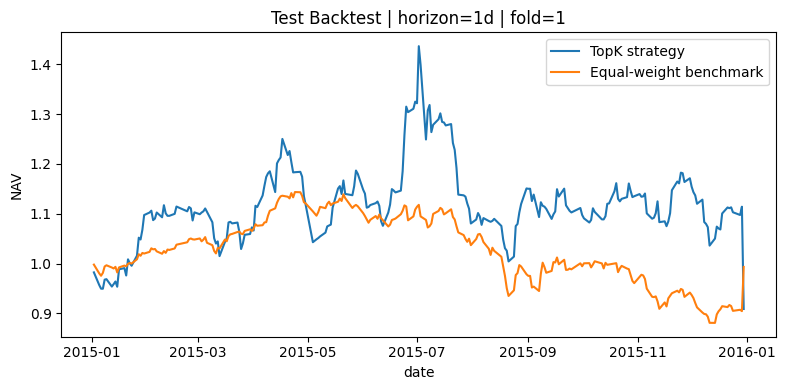

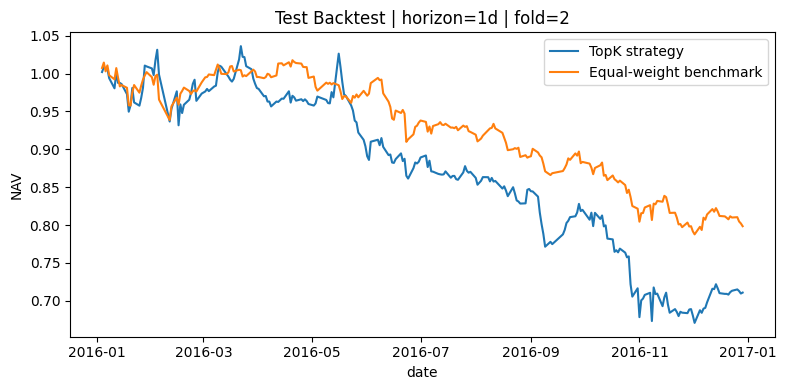

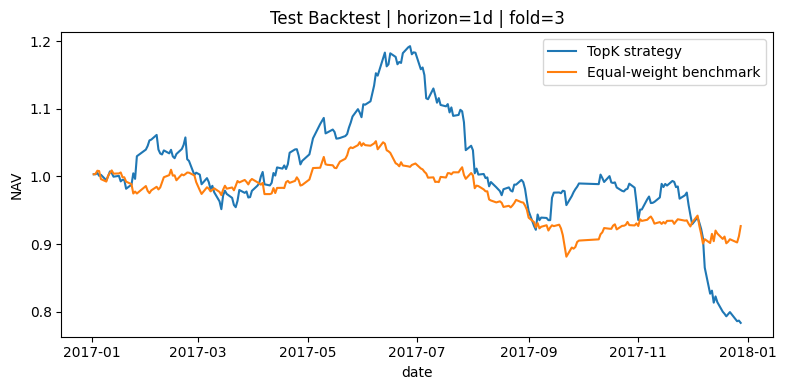

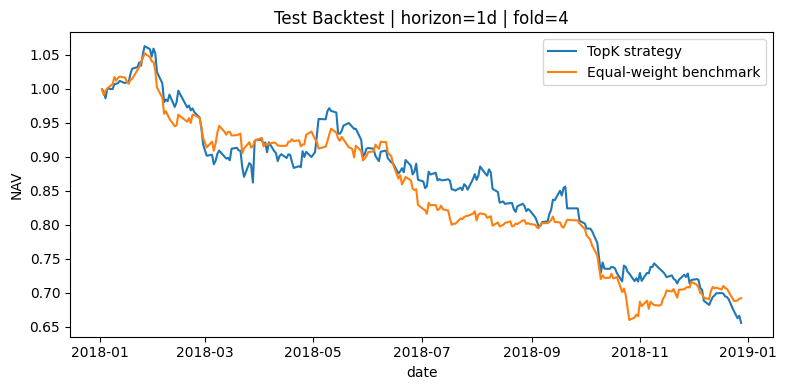

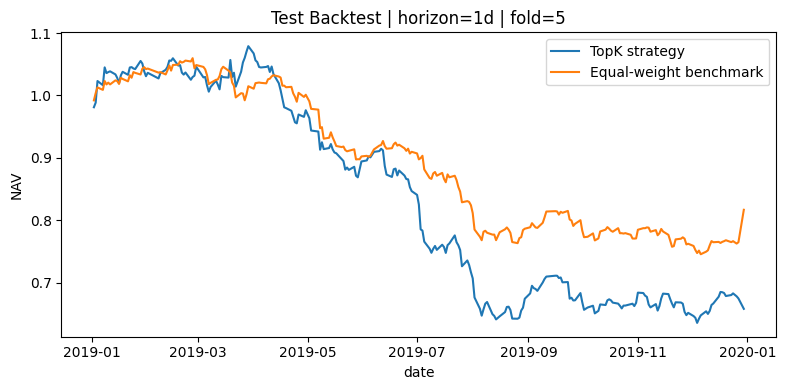

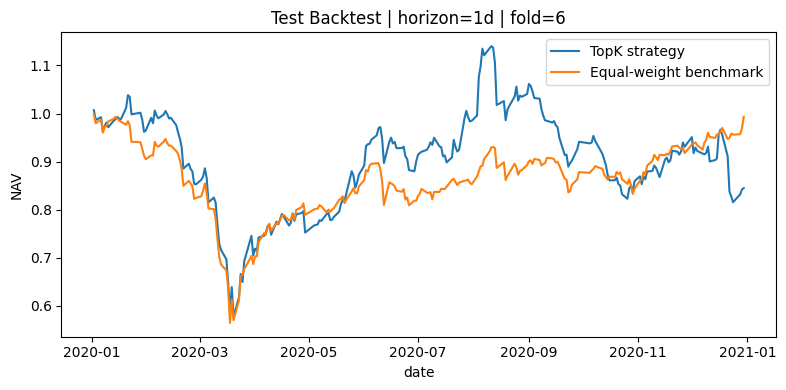

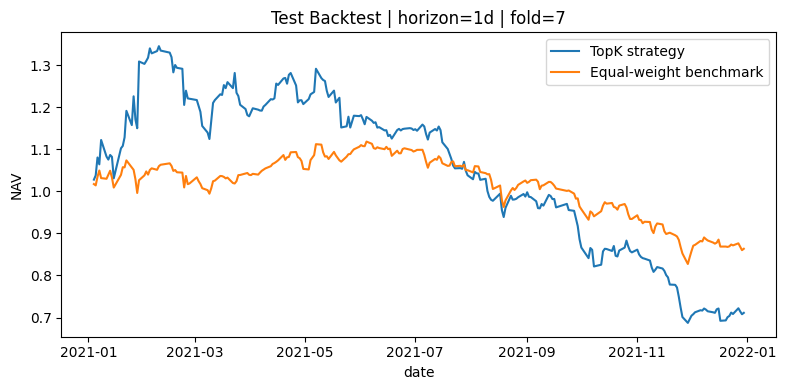

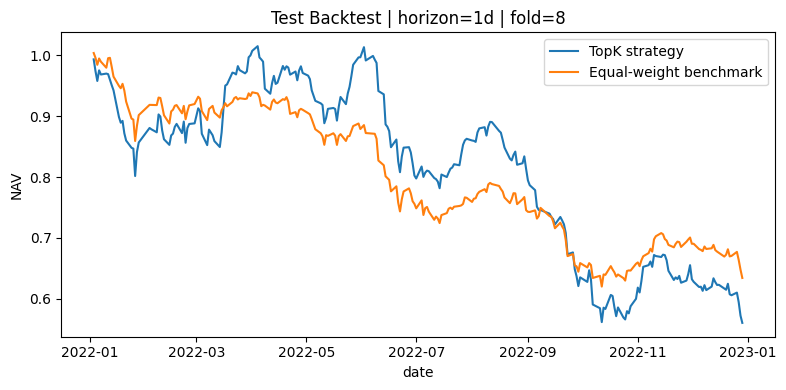

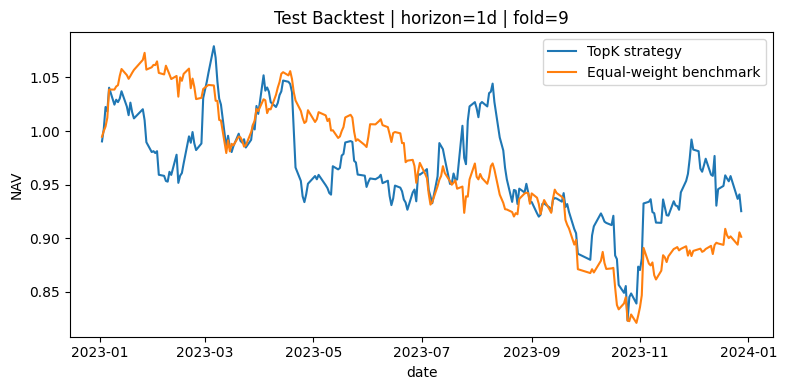

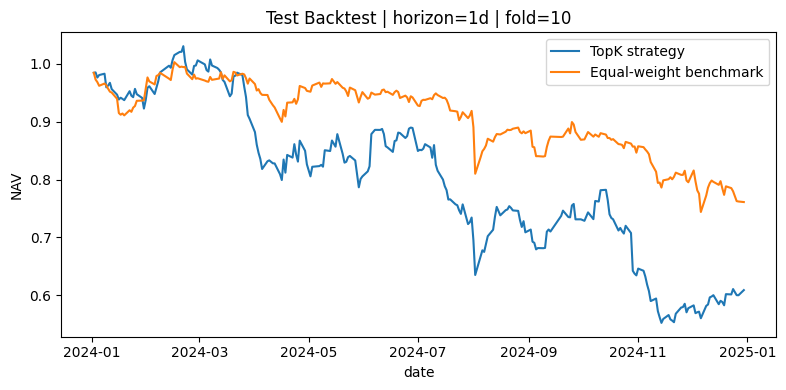

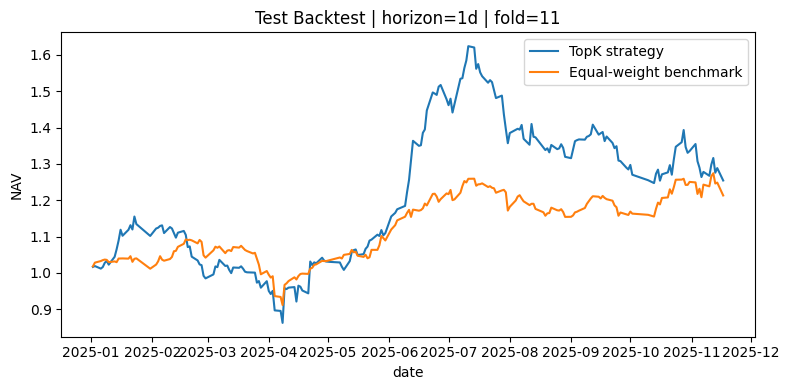

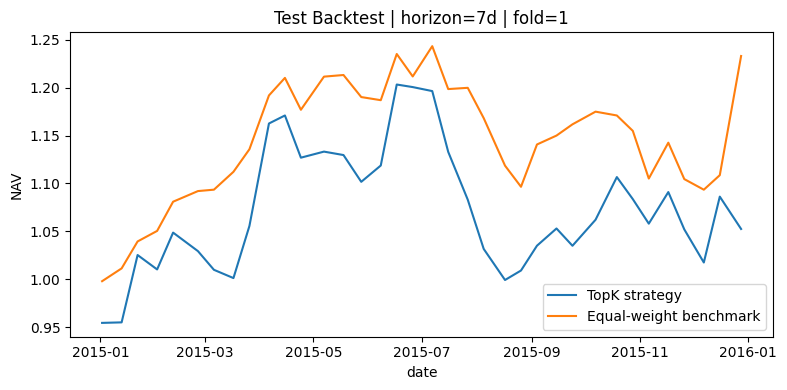

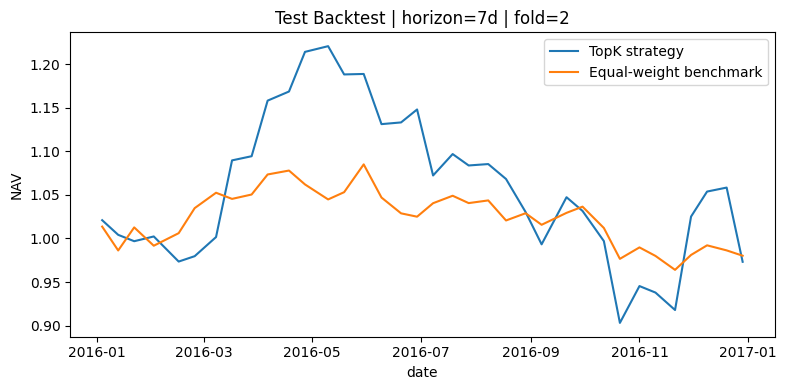

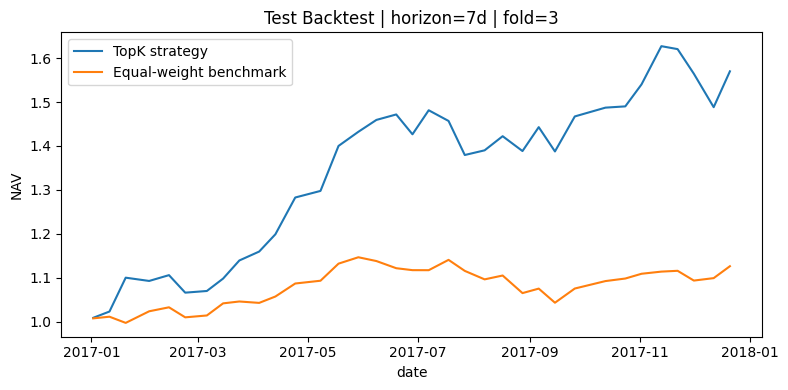

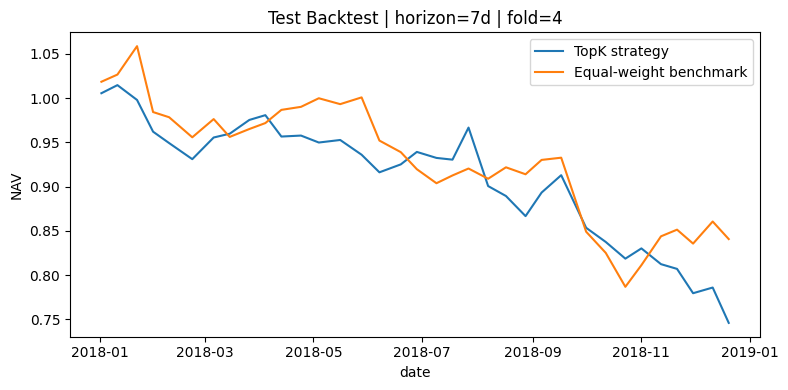

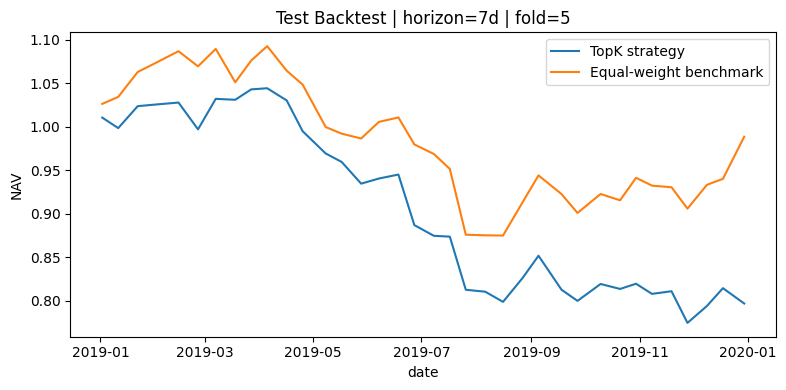

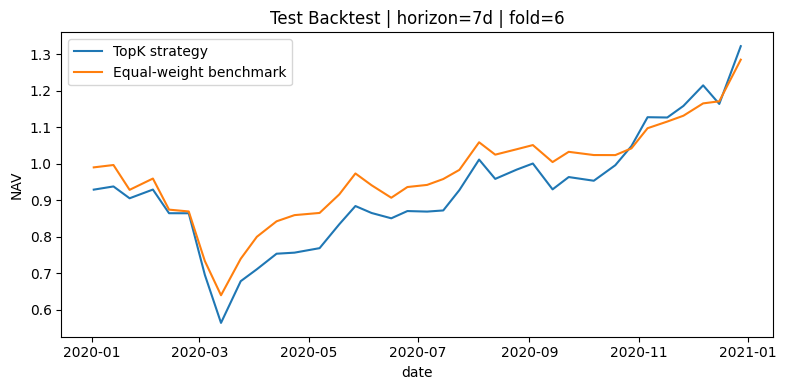

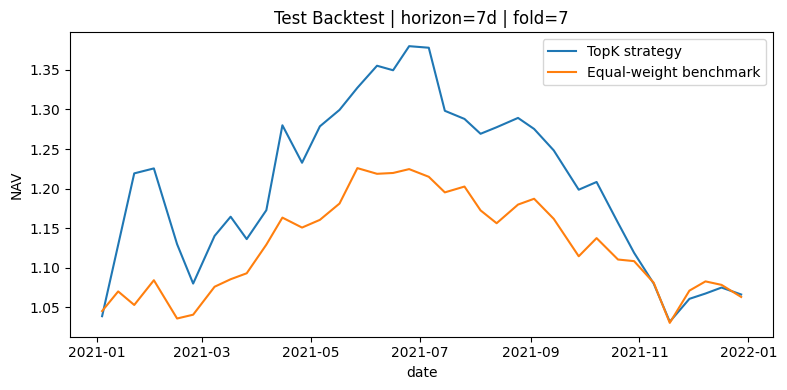

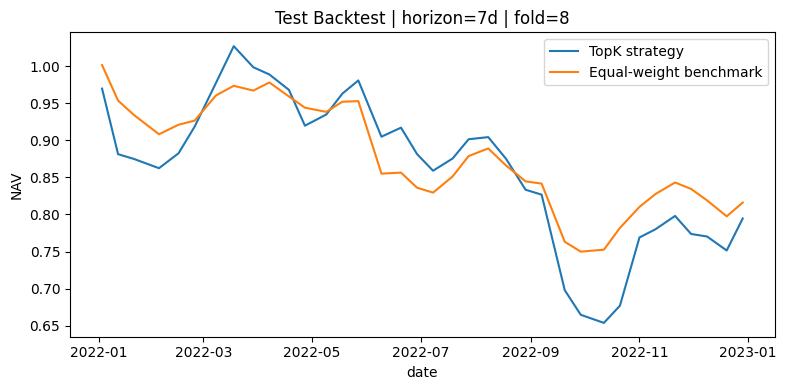

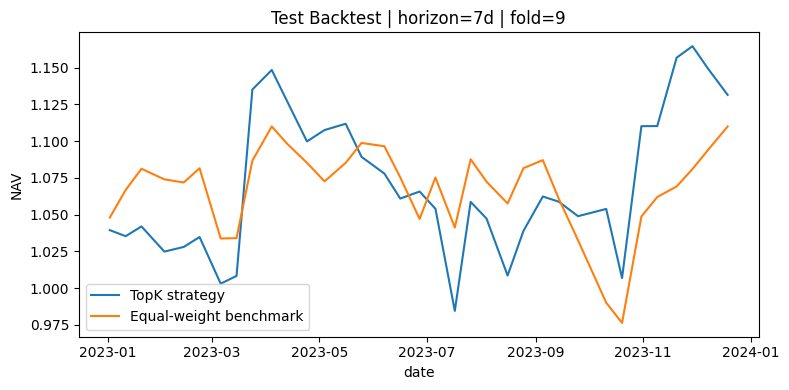

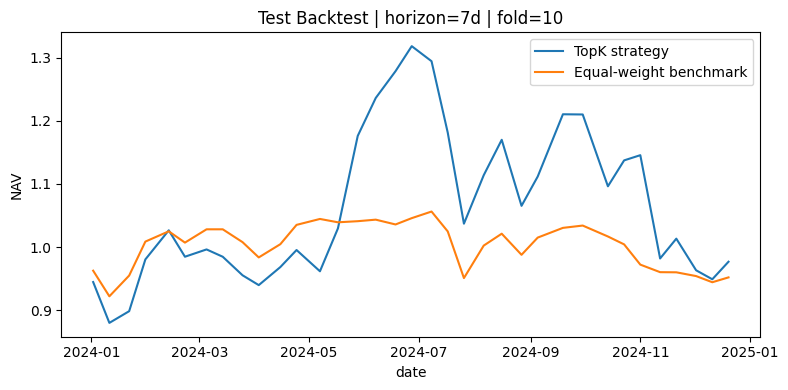

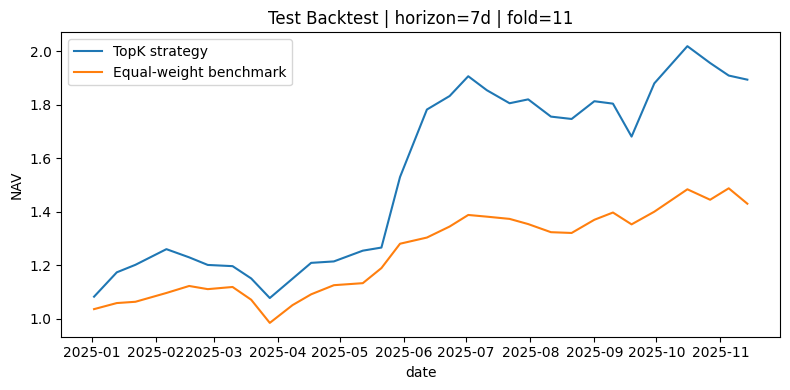

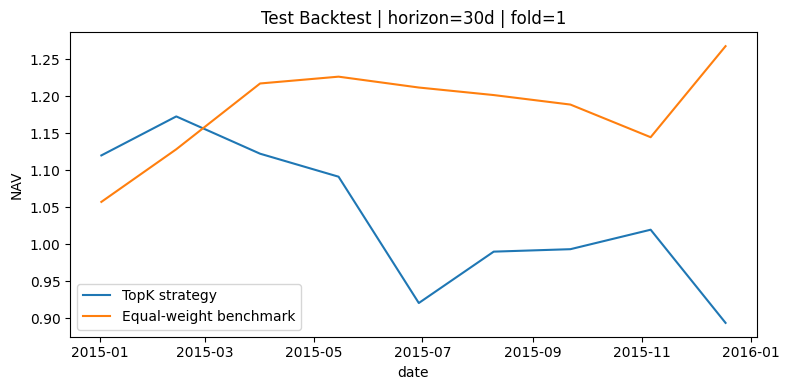

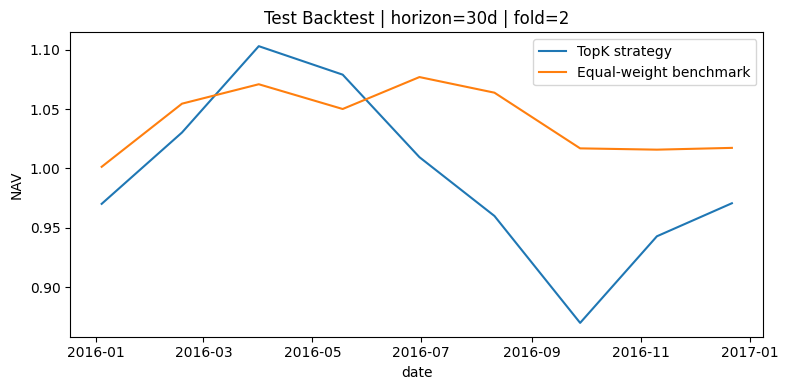

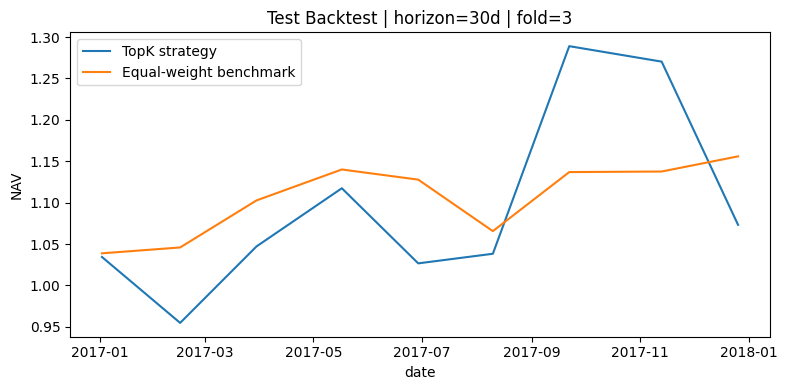

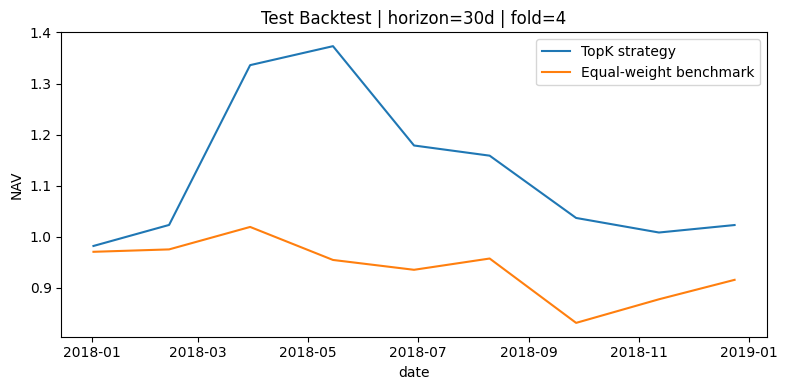

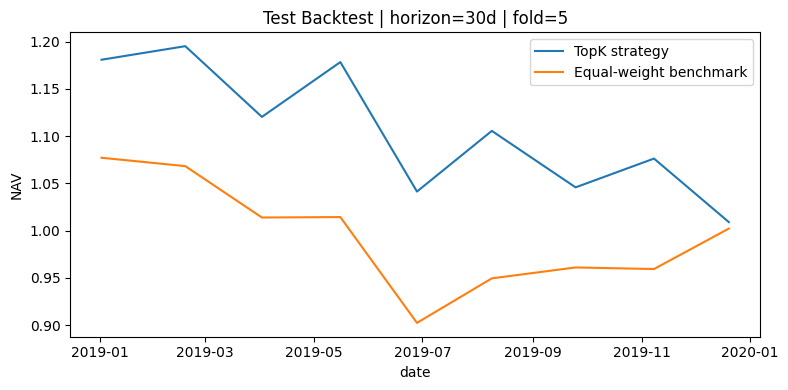

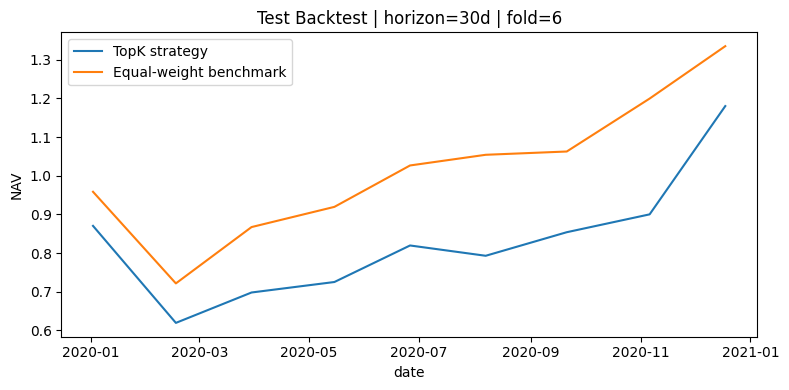

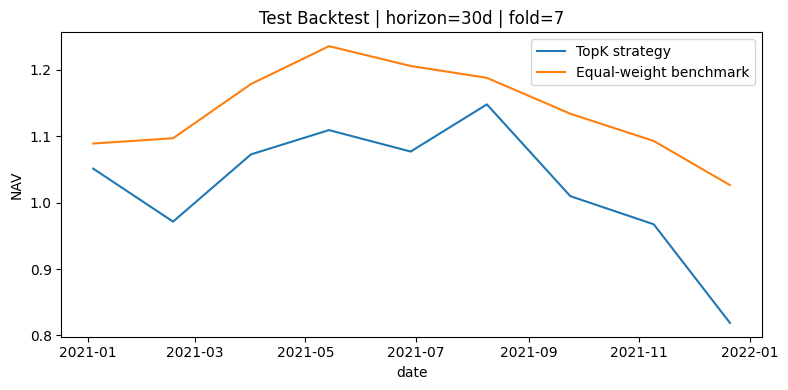

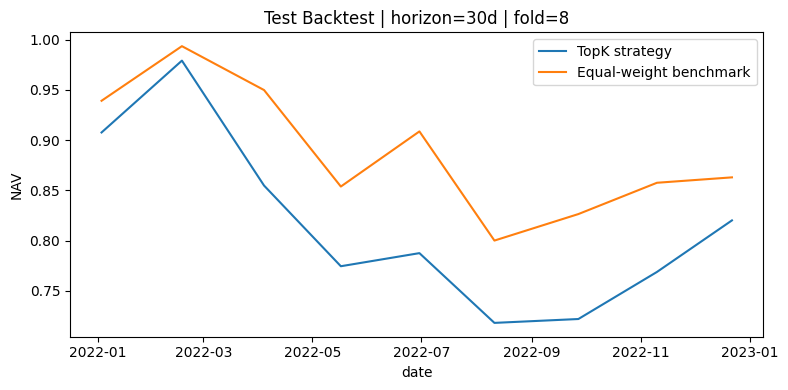

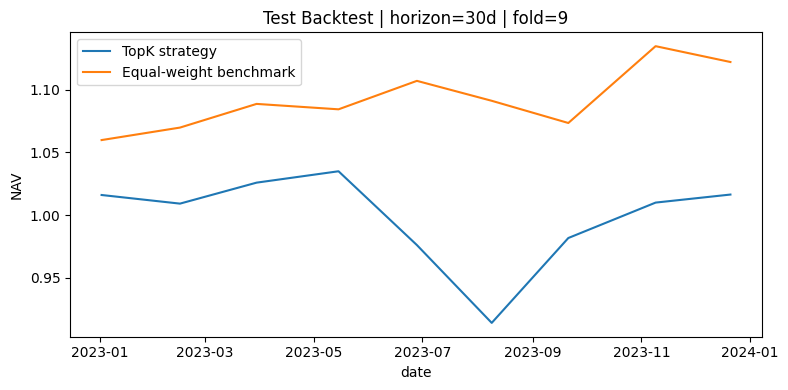

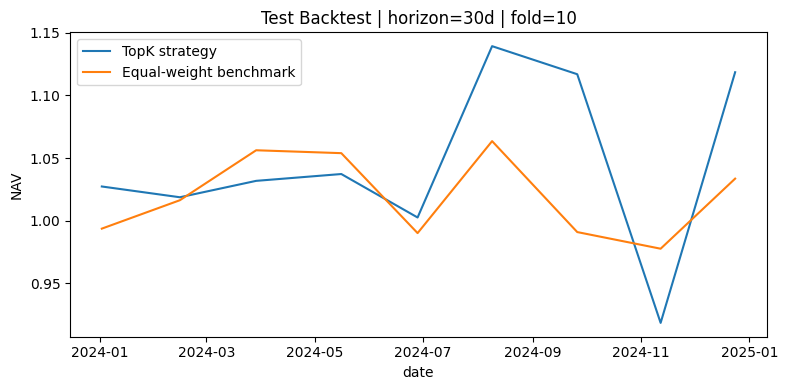

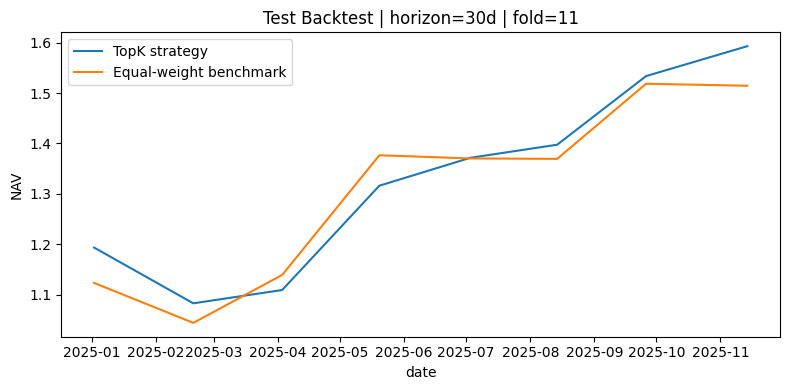

In [20]:
if len(backtest_df) > 0:
    for h in CFG.HORIZONS:
        plot_df = backtest_df[(backtest_df["split"] == "test") & (backtest_df["horizon"] == h)].copy()
        if len(plot_df) == 0:
            continue

        # fold가 여러 개라 날짜가 겹치지 않을 수도 있으므로 fold별로 따로 그립니다.
        for fold, fold_df in plot_df.groupby("fold"):
            fold_df = fold_df.sort_values("date")
            plt.figure(figsize=(8, 4))
            plt.plot(fold_df["date"], fold_df["nav"], label="TopK strategy")
            plt.plot(fold_df["date"], fold_df["benchmark_nav"], label="Equal-weight benchmark")
            plt.title(f"Test Backtest | horizon={h}d | fold={fold}")
            plt.xlabel("date")
            plt.ylabel("NAV")
            plt.legend()
            plt.tight_layout()
            plt.show()

In [24]:
RUN_FINAL_MODEL: bool = True

## 16. 최종 모델 학습

최종 모델은 최신일 예측용입니다.

여기서는 라벨이 존재하는 전체 과거 데이터를 사용합니다. 단, early stopping을 위해 마지막 10% 날짜를 내부 valid로 사용합니다.

중요:

- 이 `final_model`은 최신일 Top5 예측에만 사용합니다.
- valid/test 성능 평가에는 이미 위에서 학습한 fold별 `eval_model`만 사용했습니다.

In [28]:

def train_final_model(df: pd.DataFrame):
    """
    전체 라벨 데이터를 사용해 최신 예측용 final_model을 학습합니다.

    메모리 주의:
      walk-forward 검증 직후 final_model까지 이어서 학습하면 Colab RAM이 부족할 수 있습니다.
      CFG.RUN_FINAL_MODEL=False인 경우 이 셀은 학습을 건너뜁니다.
    """
    usable = df[df["has_full_lookback"] & df[target_cols].notna().all(axis=1)].copy()
    unique_dates = np.array(sorted(usable["date"].unique()))
    split_date = unique_dates[int(len(unique_dates) * 0.90)]

    train_idx = usable.index[usable["date"] <= split_date].to_numpy()
    valid_idx = usable.index[usable["date"] > split_date].to_numpy()

    train_idx = filter_valid_end_indices(df, train_idx, target_cols)
    valid_idx = filter_valid_end_indices(df, valid_idx, target_cols)

    scaler = fit_scaler_on_train(df, train_idx, feature_cols)
    scaled_features = make_scaled_feature_matrix(df, feature_cols, scaler)

    train_loader = make_loader_from_indices(
        df=df,
        end_indices=train_idx,
        scaled_features=scaled_features,
        target_cols=target_cols,
        shuffle=True,
    )
    valid_loader = make_loader_from_indices(
        df=df,
        end_indices=valid_idx,
        scaled_features=scaled_features,
        target_cols=target_cols,
        shuffle=False,
    )

    y_valid = get_y_array(df, valid_idx, target_cols)

    print(f"final_model train samples: {len(train_idx):,}")
    print(f"final_model valid samples: {len(valid_idx):,}")

    model, history = train_model_from_loaders(
        input_size=len(feature_cols),
        output_size=len(CFG.HORIZONS),
        train_loader=train_loader,
        valid_loader=valid_loader,
        y_valid=y_valid,
    )

    # 최신 예측에서 scaled_features를 다시 만들지 않도록 함께 반환합니다.
    return model, scaler, history


if CFG.RUN_FINAL_MODEL:
    final_model, final_scaler, final_history = train_final_model(df)
else:
    final_model, final_scaler, final_history = None, None, None
    print("CFG.RUN_FINAL_MODEL=False 이므로 final_model 학습을 건너뜁니다.")
    print("walk-forward 검증 결과를 먼저 확인한 뒤, 최신 Top5 예측이 필요하면 True로 변경해서 이 셀부터 다시 실행하세요.")


final_model train samples: 688,661
final_model valid samples: 77,066
epoch 01 | train_loss=0.006042 | valid_loss=0.008205
epoch 02 | train_loss=0.005681 | valid_loss=0.008279
epoch 03 | train_loss=0.005508 | valid_loss=0.008535
epoch 04 | train_loss=0.005352 | valid_loss=0.008769
epoch 05 | train_loss=0.005227 | valid_loss=0.008916
epoch 06 | train_loss=0.005125 | valid_loss=0.008983
early stopping: 5 epochs 동안 valid 개선 없음


## 17. 최신일 기준 Top5 예측

최신 날짜의 각 종목에 대해 최근 20거래일 시퀀스를 만들고, 1/7/30거래일 후 예상 초과수익률을 예측합니다.

출력값 해석:

- `pred_target_*d`: 모델이 예측한 target입니다.
  - `TARGET_MODE='market_excess'`이면 시장 평균 대비 초과수익률 예측값입니다.
- `pred_target_pct`: 보기 좋게 %로 변환한 값입니다.
- 실제 예상 주가를 계산하려면 raw 수익률 예측 모델이 더 적합합니다. 현재는 초과수익률 모델이므로 `predicted_price`는 출력하지 않습니다.

In [29]:

if final_model is None:
    print("final_model이 아직 없습니다. CFG.RUN_FINAL_MODEL=True로 변경한 뒤 16번 셀부터 다시 실행하세요.")
else:
    latest_date = df["date"].max()
    latest_idx = df.index[(df["date"] == latest_date) & (df["has_full_lookback"])].to_numpy()
    latest_idx = filter_valid_end_indices(df, latest_idx, target_cols=None)

    latest_scaler = final_scaler
    latest_scaled_features = make_scaled_feature_matrix(df, feature_cols, latest_scaler)

    latest_loader = make_loader_from_indices(
        df=df,
        end_indices=latest_idx,
        scaled_features=latest_scaled_features,
        target_cols=None,
        shuffle=False,
    )

    latest_meta = get_meta_frame(df, latest_idx)
    latest_pred = predict_model(final_model, latest_loader)
    latest_pred_df = latest_meta.copy()

    for j, h in enumerate(CFG.HORIZONS):
        latest_pred_df[f"pred_target_{h}d"] = latest_pred[:, j]

    ranking_tables = []
    for h in CFG.HORIZONS:
        pred_col = f"pred_target_{h}d"
        topk = latest_pred_df.nlargest(CFG.TOP_K, pred_col).copy()
        topk["horizon"] = h
        topk["rank"] = range(1, len(topk) + 1)
        topk["pred_target_pct"] = topk[pred_col] * 100

        out_cols = ["horizon", "rank", "date", "ticker"]
        for c in ["name", "sector", "industry"]:
            if c in topk.columns:
                out_cols.append(c)
        out_cols += ["close", "pred_target_pct"]

        ranking_tables.append(topk[out_cols])

    final_ranking = pd.concat(ranking_tables, ignore_index=True)

    print("예측 기준일:", latest_date.date())
    print("target mode:", CFG.TARGET_MODE)
    display(final_ranking)


예측 기준일: 2025-12-30
target mode: market_excess


,horizon,rank,date,ticker,close,pred_target_pct
0,1,1,2025-12-30,329180,509000,2.270508
1,1,2,2025-12-30,373220,368500,1.058960
2,1,3,2025-12-30,000810,497000,0.217247
3,1,4,2025-12-30,051910,333000,0.213623
4,1,5,2025-12-30,489790,44900,0.049591
5,7,1,2025-12-30,032640,14720,0.448608
6,7,2,2025-12-30,036460,39300,0.409698
7,7,3,2025-12-30,000240,26150,0.407410
8,7,4,2025-12-30,016360,75400,0.341415
9,7,5,2025-12-30,028670,3850,0.305939


## 18. 결과 저장

학습 결과, 평가 결과, Top5 예측 결과를 파일로 저장합니다.

In [30]:

OUTPUT_DIR = Path("kospi200_lstm_sequence_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

metrics_path = OUTPUT_DIR / "metrics_walk_forward.csv"
topk_path = OUTPUT_DIR / "topk_summary_walk_forward.csv"
backtest_path = OUTPUT_DIR / "backtest_walk_forward.csv"
ranking_path = OUTPUT_DIR / "latest_top5_predictions.csv"
model_path = OUTPUT_DIR / "final_lstm_model.pt"

metrics_df.to_csv(metrics_path, index=False, encoding="utf-8-sig")
topk_summary_df.to_csv(topk_path, index=False, encoding="utf-8-sig")
backtest_df.to_csv(backtest_path, index=False, encoding="utf-8-sig")

if "final_ranking" in globals():
    final_ranking.to_csv(ranking_path, index=False, encoding="utf-8-sig")

if final_model is not None:
    # PyTorch 모델 저장
    # 모델 구조를 다시 만들 수 있도록 설정값과 feature 목록도 같이 저장합니다.
    torch.save({
        "model_state_dict": final_model.state_dict(),
        "feature_cols": feature_cols,
        "target_cols": target_cols,
        "horizons": CFG.HORIZONS,
        "lookback": CFG.LOOKBACK,
        "target_mode": CFG.TARGET_MODE,
        "input_size": len(feature_cols),
        "hidden_size": CFG.HIDDEN_SIZE,
        "num_layers": CFG.NUM_LAYERS,
        "dropout": CFG.DROPOUT,
    }, model_path)

print("저장 완료")
print("metrics:", metrics_path)
print("topk:", topk_path)
print("backtest:", backtest_path)

if "final_ranking" in globals():
    print("ranking:", ranking_path)
else:
    print("ranking: final_model을 학습하지 않아 저장하지 않았습니다.")

if final_model is not None:
    print("model:", model_path)
else:
    print("model: final_model을 학습하지 않아 저장하지 않았습니다.")


저장 완료
metrics: kospi200_lstm_sequence_outputs/metrics_walk_forward.csv
topk: kospi200_lstm_sequence_outputs/topk_summary_walk_forward.csv
backtest: kospi200_lstm_sequence_outputs/backtest_walk_forward.csv
ranking: kospi200_lstm_sequence_outputs/latest_top5_predictions.csv
model: kospi200_lstm_sequence_outputs/final_lstm_model.pt


## 19. 현재 모델 구조 정리

### 입력 데이터 형식

```text
X shape = (샘플 수, 20, 피처 수)
```

각 샘플은 다음 의미입니다.

```text
특정 종목의 특정 기준일 t에 대해,
t-19 ~ t까지 최근 20거래일의 피처 배열
```

예:

```text
삼성전자 2023-12-29 샘플
= 삼성전자 최근 20거래일 OHLCV 기반 피처 배열
```

### 출력값 형식

```text
y shape = (샘플 수, 3)
```

3개 출력은 각각 다음입니다.

```text
1거래일 후 target
7거래일 후 target
30거래일 후 target
```

기본 설정에서는 `TARGET_MODE='market_excess'`이므로, 출력값은 단순 수익률이 아니라 **시장 평균 대비 초과수익률**입니다.

즉, 모델이 예측하는 것은 아래 질문입니다.

```text
이 종목은 앞으로 1/7/30거래일 동안 KOSPI200 평균보다 더 강할 것인가?
```

## 20. 자체 검토 및 추가 개선사항

이 노트북은 기존 baseline 대비 다음 문제를 개선했습니다.

1. **평가 누수 제거**
   - valid/test 평가는 fold별 `eval_model`만 사용합니다.
   - 전체 데이터로 학습한 `final_model`은 최신일 예측에만 사용합니다.

2. **1행 입력 → 20일 시퀀스 입력**
   - 기존에는 `ret_20d`, `ma_gap_20d` 같은 요약 피처만 봤습니다.
   - 이제는 최근 20거래일의 변화 패턴을 LSTM이 직접 볼 수 있습니다.

3. **단순수익률 → 초과수익률 target**
   - 시장 전체 상승/하락보다 상대적으로 강한 종목을 찾는 문제로 바꿨습니다.

4. **walk-forward validation 적용**
   - 과거로 학습하고 미래로 평가하는 구조를 여러 번 반복합니다.

5. **TopK 평가와 백테스트 추가**
   - MAE/RMSE뿐 아니라 실제 목적에 가까운 Top5 성과를 확인합니다.

추가 개선 후보는 다음입니다.

1. **raw 수익률 모델과 초과수익률 모델을 분리**
   - TopK 선정은 초과수익률 모델이 적합합니다.
   - 예상 가격 출력은 raw 수익률 모델이 더 적합합니다.

2. **Transformer Encoder 비교 실험**
   - LSTM은 순차 정보를 압축해서 봅니다.
   - Transformer는 20일 구간 안에서 특정 날짜의 중요도를 attention으로 볼 수 있습니다.

3. **종목 ID embedding 추가**
   - 현재는 ticker를 입력하지 않습니다.
   - ticker embedding을 추가하면 종목별 고유 특성을 학습할 수 있지만, 과적합 위험도 있습니다.

4. **업종 embedding 추가**
   - sector/industry를 범주형 embedding으로 넣으면 업종별 패턴을 더 직접적으로 반영할 수 있습니다.

5. **더 엄밀한 백테스트**
   - 거래정지, 상장폐지, 거래대금 부족, 슬리피지, 종목별 최대 비중, 중복 보유를 반영해야 합니다.

6. **ranking loss 적용**
   - 현재는 MSE 회귀입니다.
   - 실제 목적은 TopK 랭킹이므로 pairwise/listwise ranking loss가 더 적합할 수 있습니다.